




# Mortgage task

Let's have a look at how ml can help us to improve metrics of mortgage and make the right decision about it

## Mortgage task

The company deals with mortgage. It has 25 billion rubles which it can lend within one year. The goal of the company is to get a maximum profit from its investment.

Details:
1. The company issues mortgage according to `__priority` column. In the first place the company issues mortgage to the clients with maximum value of `__priority` until the account has no money.

> Example: Our account has 50 rubles and we have only three mortgage requests [20, 30, 50] rubles with priority [0.5, 1, 0.3] respectively. The first mortgage will be issued for 30 rubles (the highest priority which is equal to 1). Our account has 20 rubles after this deal (50 - 30). The second mortgage will be issued for 20 rubles (priority = 0.5). The mortgage issue process will stop, because our account has 0 rubles after the deal.

2. The mortgage is considered issued if the company has money on the account and the predicted value is in the range within +/- 10% of real price.

> Example:
> The price of the real estate is 10 million rubles. The mortgage will be issued if predicted price is in the range within +/- 10%
> - from 9 to 10 millions rubles, mortgage will be issued for **predicted** price
> - from 10 to 11 millions rubles, mortgage will be issued for **real** price (10 million)

3. Some clients may go into debt. In this case the profit will be negative (see function `call_all_metrics` for more details)

> Example:
> 	We have only 3 mortgage loans worth [10, 30, 50] rubles and some clients get into debt [no, yes, no] respectively. In this case, we only get profit from clients 1,3 from client 2 we have loss (see detail coefficients in function `call_all_metrics`)

4. The profit is formed as percentage of the cost of the mortgage. (for exact coefficients see the function `calc_all_metrics`)

# Minimal Viable Product

Your team has already collected a training dataset (`train`) with the most important features for the client and for the purchased apartment (59 features in total) and 2 target variables.
Trained 2 ML models and wrote an algorithm that generates a new column (`__priority`) in the dataset in which there will be a priority for issuing loans.

Target variables:
1. `__price_doc` - real cost of building, million rubles
2. `__churn` - the fact that the client has gone into debt, 1 - debt, 0 - no

Columns with predictions:
1. `__price_predict` - predicted value of real estate, in million rubles (from 0 to infinity)
2. `__churn_prob` - predicted probability that the client will go into debt, probability (from 0 to 1 inclusive)
3. `__priority` - priority in issuing a loan (first of all, the loan is issued to clients with the highest value), (from minus infinity to + infinity)
> If the priority value is below 0, then the mortgage will not be issued under any circumstances

In [23]:
#import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.impute import KNNImputer
from sklearn.preprocessing import RobustScaler
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
import warnings

!pip install category_encoders
from category_encoders import TargetEncoder


In [24]:

pd.options.display.max_rows = 1000


NAME = "Belton_Manhica"

#read data files
train = pd.read_csv('/content/train.csv')
test = pd.read_csv('/content/0_Belton_Manhica_test.csv')

TRAIN_SHAPE, TEST_SHAPE = train.shape, test.shape
TRAIN_SHAPE, TEST_SHAPE

((20483, 61), (9183, 60))

The train data has more columns than the test one.

1. EXPLORATORY DATA ANALYSIS

In [ ]:
#show data type, and count of non-null values for all columns
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20483 entries, 0 to 20482
Data columns (total 61 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   max_floor                              10911 non-null  float64
 1   state                                  8469 non-null   float64
 2   marital_status                         20483 non-null  object 
 3   big_market_raion                       20483 non-null  object 
 4   total_revolving_bal                    20483 non-null  int64  
 5   market_count_1500                      20483 non-null  int64  
 6   leisure_count_3000                     20483 non-null  int64  
 7   total_ct_chng_q4_q1                    20483 non-null  float64
 8   water_1line                            20483 non-null  object 
 9   railroad_station_walk_km               20473 non-null  float64
 10  culture_objects_top_25                 20483 non-null  object 
 11  co

In [ ]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9183 entries, 0 to 9182
Data columns (total 60 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   Unnamed: 0                             9183 non-null   int64  
 1   max_floor                              9183 non-null   float64
 2   state                                  7768 non-null   float64
 3   marital_status                         9183 non-null   object 
 4   big_market_raion                       9183 non-null   object 
 5   total_revolving_bal                    9183 non-null   int64  
 6   market_count_1500                      9183 non-null   int64  
 7   leisure_count_3000                     9183 non-null   int64  
 8   total_ct_chng_q4_q1                    9183 non-null   float64
 9   water_1line                            9183 non-null   object 
 10  railroad_station_walk_km               9170 non-null   float64
 11  cult

*The test data is missing the following columns for __churn and __price_doc, and has one column that is not in the train data (Unnamed: 0)*

In [ ]:
train


,max_floor,state,marital_status,big_market_raion,total_revolving_bal,market_count_1500,leisure_count_3000,total_ct_chng_q4_q1,water_1line,railroad_station_walk_km,...,avg_open_to_buy,build_year,incineration_raion,full_sq,total_relationship_count,detention_facility_raion,build_count_mix,railroad_terminal_raion,__churn,__price_doc
0,NaN,NaN,Single,no,1906,1,0,0.694,no,5.419893,...,1996.9,NaN,no,43,5,no,0.0,no,0,5.850000
1,NaN,NaN,Married,no,12,0,6,0.693,no,3.411993,...,1338.4,NaN,no,34,3,no,0.0,no,0,6.000000
2,NaN,NaN,Married,no,2153,5,0,0.831,no,1.277658,...,2411.5,NaN,no,43,6,no,0.0,no,0,5.700000
3,NaN,NaN,Married,no,1806,2,0,0.638,no,4.291432,...,9255.9,NaN,no,89,3,no,2.0,no,0,13.100000
4,NaN,NaN,Married,no,753,2,40,0.902,no,0.853960,...,3318.2,NaN,no,77,4,no,1.0,yes,0,16.331452
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20478,16.0,3.0,Married,no,1377,0,0,0.762,yes,2.585823,...,10297.2,1990.0,no,37,6,yes,0.0,no,0,7.200000
20479,17.0,1.0,Married,no,1636,0,0,0.884,no,3.997038,...,2649.9,2013.0,yes,37,6,no,0.0,no,0,4.027052
20480,12.0,3.0,Married,no,1490,2,2,0.654,no,8.649008,...,3258.7,1972.0,no,45,5,no,0.0,no,0,9.650000
20481,17.0,3.0,Single,no,1220,0,0,0.722,no,9.300953,...,10548.1,2007.0,no,64,2,no,0.0,no,1,3.500000


from matplotlib import pyplot as plt
train['max_floor'].plot(kind='hist', bins=20, title='max_floor')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
train['state'].plot(kind='hist', bins=20, title='state')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
train['total_revolving_bal'].plot(kind='hist', bins=20, title='total_revolving_bal')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
train['market_count_1500'].plot(kind='hist', bins=20, title='market_count_1500')
plt.gca().spines[['top', 'right',]].set_visible(False)

...

from matplotlib import pyplot as plt
import seaborn as sns
figsize = (12, 1.2 * len(train['big_market_raion'].unique()))
plt.figure(figsize=figsize)
sns.violinplot(train, x='max_floor', y='big_market_raion', inner='box', palette='Dark2')
sns.despine(top=True, right=True, bottom=True, left=True)

<string>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.



from matplotlib import pyplot as plt
import seaborn as sns
figsize = (12, 1.2 * len(train['water_1line'].unique()))
plt.figure(figsize=figsize)
sns.violinplot(train, x='max_floor', y='water_1line', inner='box', palette='Dark2')
sns.despine(top=True, right=True, bottom=True, left=True)

<string>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.



from matplotlib import pyplot as plt
import seaborn as sns
figsize = (12, 1.2 * len(train['culture_objects_top_25'].unique()))
plt.figure(figsize=figsize)
sns.violinplot(train, x='max_floor', y='culture_objects_top_25', inner='box', palette='Dark2')
sns.despine(top=True, right=True, bottom=True, left=True)

In [ ]:
#Missing values
result = (
  train
    .isnull().sum() # count of null values
    .sort_values(ascending = False)# sort values in descending order


)
result[result>0]

,0
state,12014
build_year,11582
num_room,9572
max_floor,9572
cafe_sum_1000_min_price_avg,4596
life_sq,4193
build_count_mix,3063
build_count_wood,3063
cafe_sum_1500_min_price_avg,2998
total_trans_amt,2403


In [ ]:
#Generate descriptive statistics (dataframe.describe) #round to two decimal places
#T - transpose

train.describe(include ='number').round(2).T


,count,mean,std,min,25%,50%,75%,max
max_floor,10911.0,12.55,6.55,0.00,9.00,12.00,17.00,48.00
state,8469.0,2.19,0.89,1.00,2.00,2.00,3.00,33.00
total_revolving_bal,20483.0,1137.91,784.99,0.00,577.00,1195.00,1742.00,2517.00
market_count_1500,20483.0,0.78,1.14,0.00,0.00,0.00,1.00,7.00
leisure_count_3000,20483.0,3.59,12.34,0.00,0.00,0.00,2.00,85.00
total_ct_chng_q4_q1,20483.0,0.66,0.17,0.00,0.57,0.68,0.77,2.53
railroad_station_walk_km,20473.0,4.31,3.76,0.03,1.92,3.21,5.17,24.65
contacts_count_12_mon,20483.0,2.28,0.54,0.00,2.00,2.00,3.00,6.00
0_17_all,18080.0,12724.00,9286.40,411.00,3831.00,12508.00,17354.00,45170.00
trc_count_2000,20483.0,5.92,6.15,0.00,1.00,5.00,9.00,37.00


In [ ]:
#descriptive statistics of the object
train.describe(include = 'object').T

,count,unique,top,freq
marital_status,20483,2,Married,11524
big_market_raion,20483,2,no,18591
water_1line,20483,2,no,18837
culture_objects_top_25,20483,2,no,19367
product_type,20483,2,Investment,13440
big_road1_1line,20483,2,no,19940
card_category,20483,3,Blue,19839
income_category,20483,6,Less than $40K,9604
thermal_power_plant_raion,20483,2,no,19372
radiation_raion,20483,2,no,13133


In [ ]:
train.sample(5).T #returns a random sample of items from an axis of objects


,1094,1340,12016,7867,7263
max_floor,NaN,NaN,17.0,NaN,NaN
state,NaN,NaN,NaN,NaN,NaN
marital_status,Married,Married,Married,Married,Single
big_market_raion,no,no,no,no,yes
total_revolving_bal,1804,1180,1685,2182,593
market_count_1500,0,0,1,2,0
leisure_count_3000,6,0,0,0,0
total_ct_chng_q4_q1,0.748,0.443,0.438,0.704,0.684
water_1line,no,no,no,no,no
railroad_station_walk_km,1.314218,7.267386,0.696977,3.213866,10.745473


In [26]:
corr = train.corr(numeric_only=True) #compute pairwise correlation of columns, exclusing NA/null values
corr

#all columns are not highly correlated.

,max_floor,state,total_revolving_bal,market_count_1500,leisure_count_3000,total_ct_chng_q4_q1,railroad_station_walk_km,contacts_count_12_mon,0_17_all,trc_count_2000,...,num_room,months_on_book,dependent_count,avg_open_to_buy,build_year,full_sq,total_relationship_count,build_count_mix,__churn,__price_doc
max_floor,1.000000,-0.042611,-0.017500,-0.081176,-0.033585,0.002234,-0.023776,-0.008980,-0.016407,-0.041015,...,-0.027052,0.008760,-0.002224,-0.000544,-0.000218,0.141272,0.010638,0.066154,-0.013019,0.092191
state,-0.042611,1.000000,-0.001783,0.116845,-0.052471,-0.014412,-0.168889,0.009713,0.280185,0.145232,...,0.077215,0.000581,0.005979,0.007727,0.408325,-0.079604,0.012606,0.031238,0.000725,0.137082
total_revolving_bal,-0.017500,-0.001783,1.000000,0.017403,0.011010,0.064204,-0.009119,-0.197059,-0.006645,0.005348,...,-0.012387,-0.002289,-0.047848,-0.053644,-0.000942,0.007275,0.116317,0.004219,-0.209078,-0.001268
market_count_1500,-0.081176,0.116845,0.017403,1.000000,0.179860,0.005297,-0.188313,-0.000168,0.313543,0.345236,...,0.026592,0.001544,-0.002826,-0.006537,-0.008028,-0.027621,0.016026,-0.011309,-0.008397,0.098769
leisure_count_3000,-0.033585,-0.052471,0.011010,0.179860,1.000000,0.001300,-0.124539,-0.006708,-0.009419,0.681092,...,0.030633,0.005634,-0.009359,-0.010427,0.000303,0.022345,0.023718,0.023830,-0.008955,0.111823
total_ct_chng_q4_q1,0.002234,-0.014412,0.064204,0.005297,0.001300,1.000000,-0.005011,-0.310530,-0.006567,0.002147,...,0.014380,-0.031291,-0.021720,-0.055342,-0.007549,0.008128,0.121730,0.007433,-0.424119,0.001959
railroad_station_walk_km,-0.023776,-0.168889,-0.009119,-0.188313,-0.124539,-0.005011,1.000000,0.007989,-0.296284,-0.275789,...,-0.022217,0.004703,-0.003339,-0.005287,0.004759,0.043883,-0.013643,-0.140312,0.011722,-0.121806
contacts_count_12_mon,-0.008980,0.009713,-0.197059,-0.000168,-0.006708,-0.310530,0.007989,1.000000,-0.000743,-0.001862,...,-0.008438,-0.035916,-0.020859,0.018851,-0.005459,0.004697,-0.209157,-0.004783,0.555666,0.002368
0_17_all,-0.016407,0.280185,-0.006645,0.313543,-0.009419,-0.006567,-0.296284,-0.000743,1.000000,0.382519,...,0.058014,-0.001117,0.000545,-0.005107,-0.001419,-0.019872,0.014142,0.202283,-0.001821,0.145585
trc_count_2000,-0.041015,0.145232,0.005348,0.345236,0.681092,0.002147,-0.275789,-0.001862,0.382519,1.000000,...,0.076153,0.010883,-0.006676,-0.010055,0.006224,-0.004976,0.030458,-0.049604,-0.004423,0.193177


<Axes: >

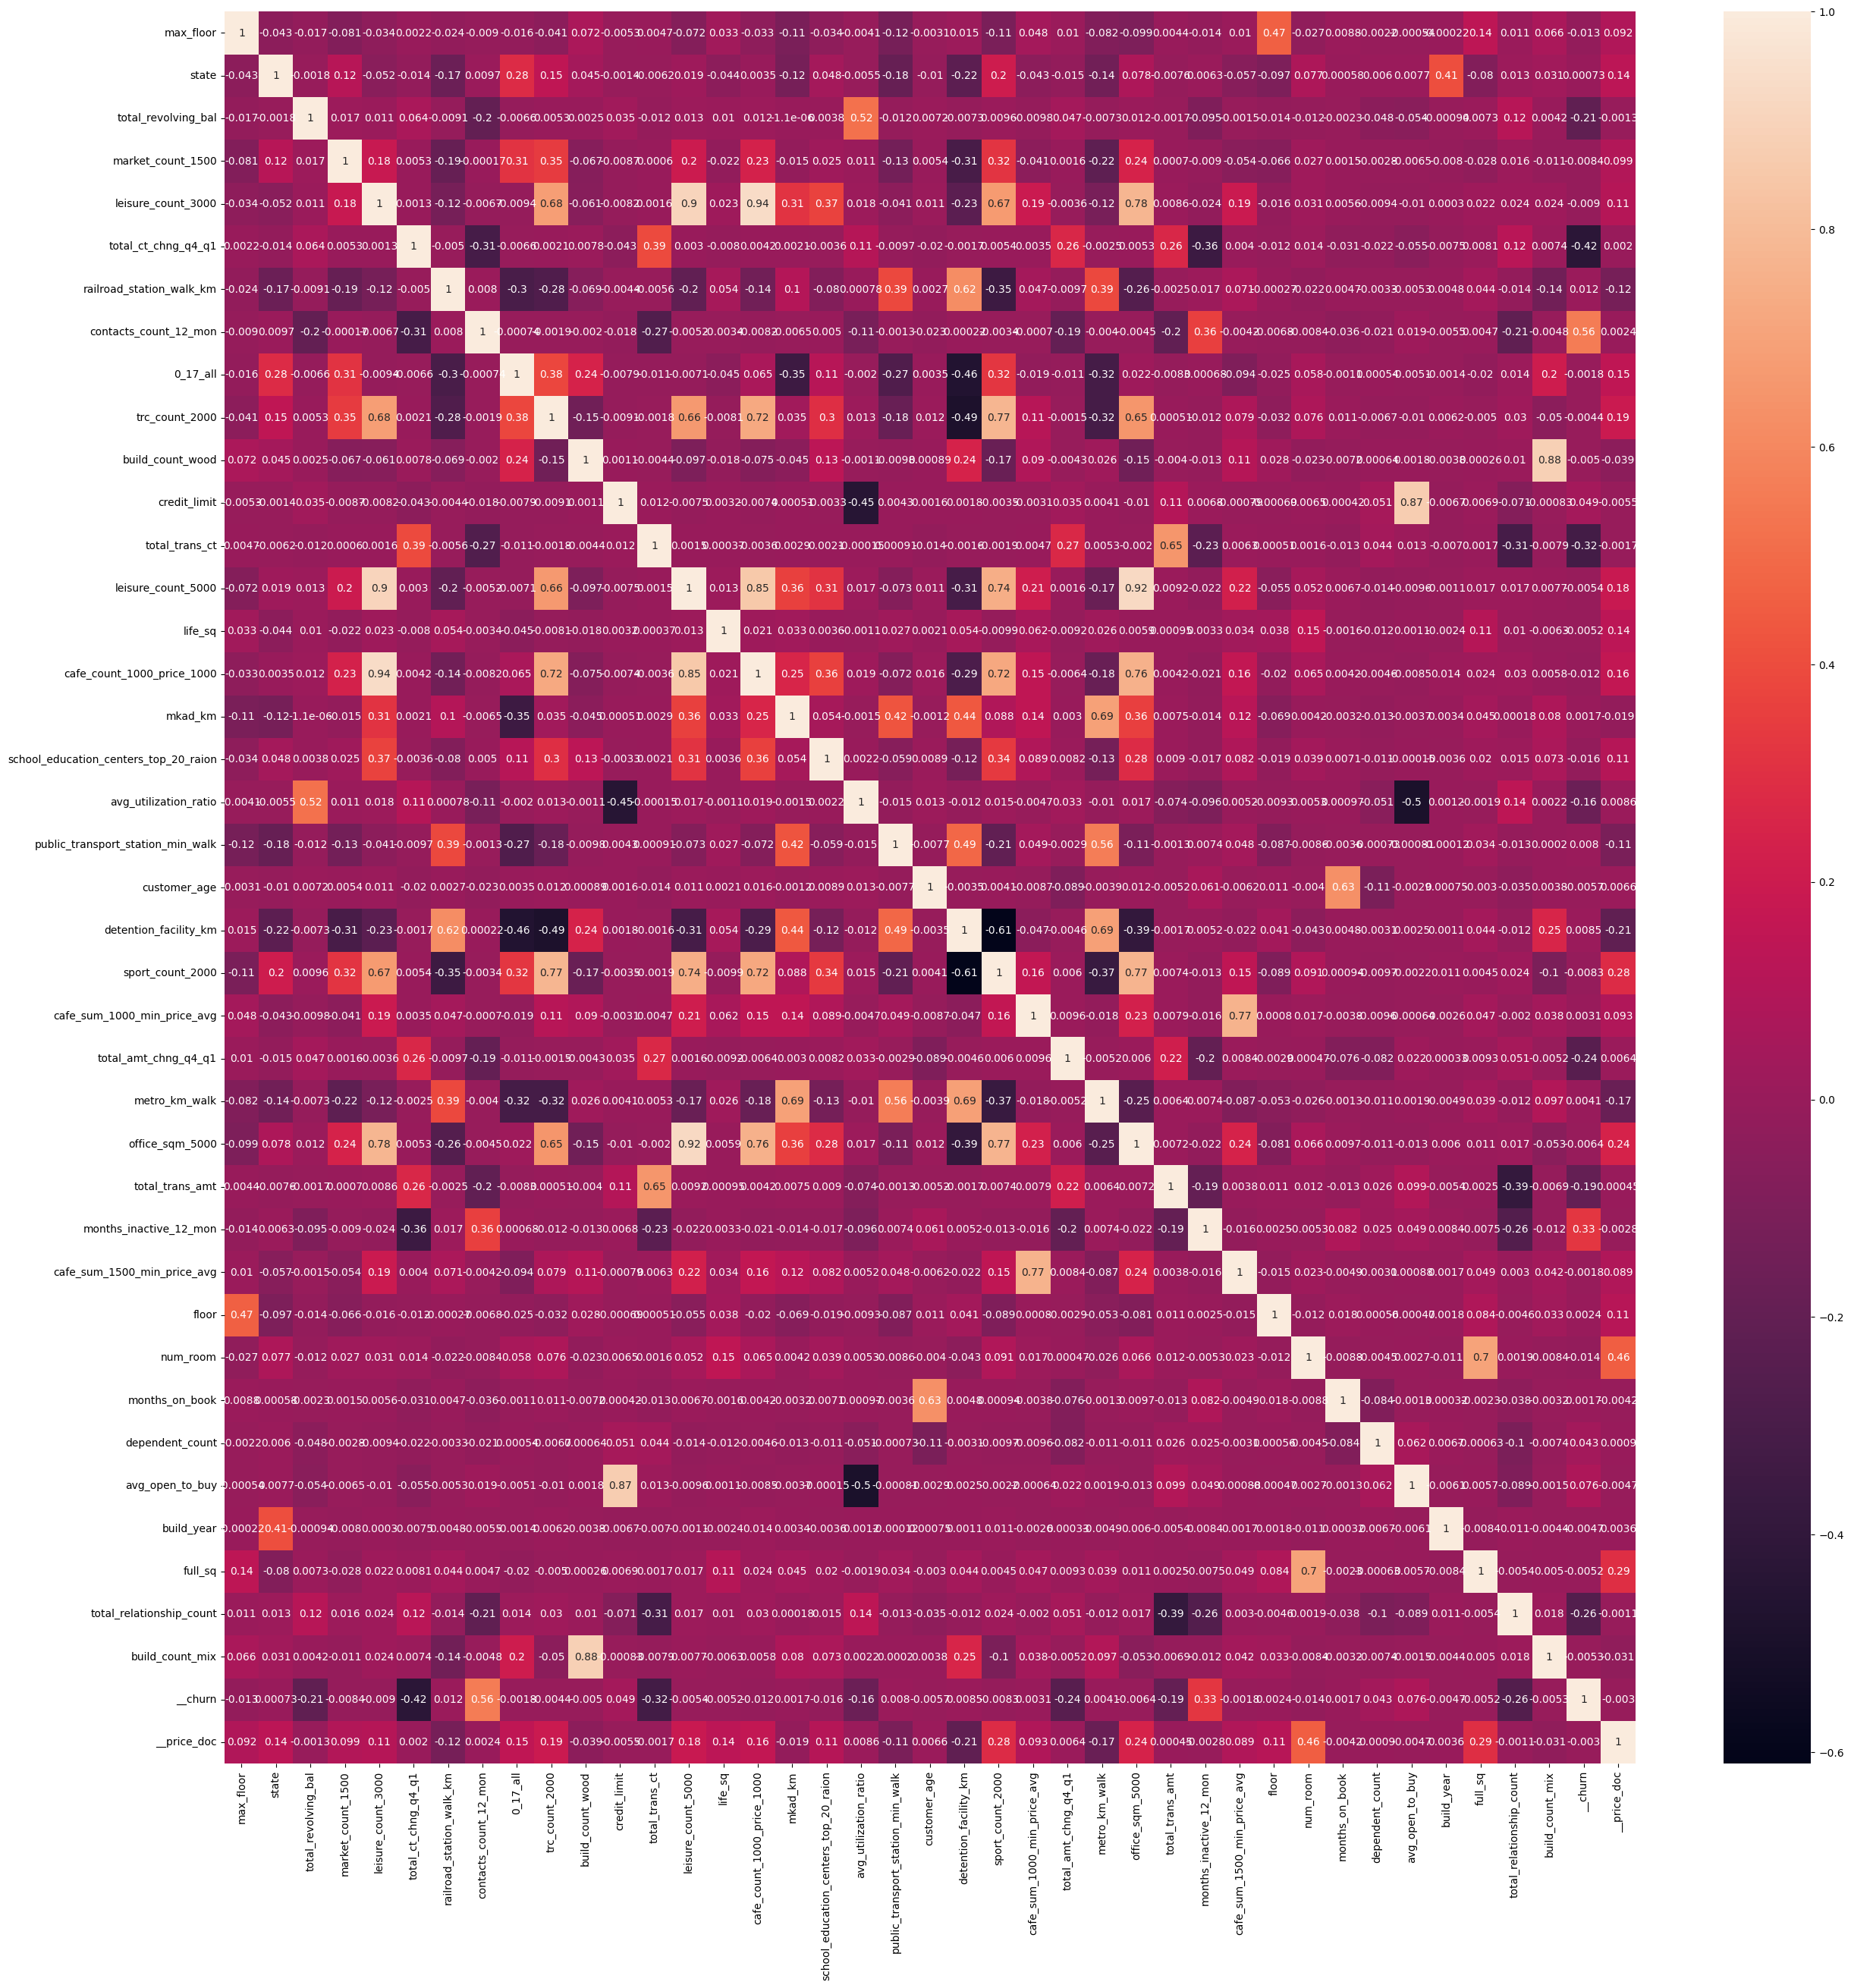

In [ ]:
#Get a correlation heat map
plt.figure(figsize=(30,30)) #get the propersize of the heatmap
sns.heatmap(corr, annot =True) #annot = True includes the values of the correlation relationship

The correlation amongst variables is very low. This means that there is no much collinearity among them.

In [27]:
corr.head().T.head().round(2)

,max_floor,state,total_revolving_bal,market_count_1500,leisure_count_3000
max_floor,1.00,-0.04,-0.02,-0.08,-0.03
state,-0.04,1.00,-0.00,0.12,-0.05
total_revolving_bal,-0.02,-0.00,1.00,0.02,0.01
market_count_1500,-0.08,0.12,0.02,1.00,0.18
leisure_count_3000,-0.03,-0.05,0.01,0.18,1.00


In [ ]:
#checking correlation with our target values
corr['__churn'].abs().sort_values(ascending=False).head(10)

,__churn
__churn,1.000000
contacts_count_12_mon,0.555666
total_ct_chng_q4_q1,0.424119
months_inactive_12_mon,0.325025
total_trans_ct,0.322356
total_relationship_count,0.259767
total_amt_chng_q4_q1,0.243586
total_revolving_bal,0.209078
total_trans_amt,0.192359
avg_utilization_ratio,0.164768


In [ ]:
corr['__price_doc'].abs().sort_values(ascending=False).head(10)

,__price_doc
__price_doc,1.000000
num_room,0.458204
full_sq,0.290589
sport_count_2000,0.278837
office_sqm_5000,0.242210
detention_facility_km,0.208426
trc_count_2000,0.193177
leisure_count_5000,0.183895
metro_km_walk,0.171779
cafe_count_1000_price_1000,0.157386


In [ ]:
#finding garbage value
train.select_dtypes(include='object').apply(lambda x: x=='..').sum()

#There are no garbage values


,0
marital_status,0
big_market_raion,0
water_1line,0
culture_objects_top_25,0
product_type,0
big_road1_1line,0
card_category,0
income_category,0
thermal_power_plant_raion,0
radiation_raion,0


In [ ]:

test.select_dtypes(include='object').apply(lambda x: x=='..').sum()

#There are no garbage values

,0
marital_status,0
big_market_raion,0
water_1line,0
culture_objects_top_25,0
product_type,0
big_road1_1line,0
card_category,0
income_category,0
thermal_power_plant_raion,0
radiation_raion,0


In [ ]:
#Checking for duplicates

train.duplicated().sum()

#no duplicates

0

In [ ]:
test.duplicated().sum()

#no duplicates

0

2. DATA PREPROCESSING

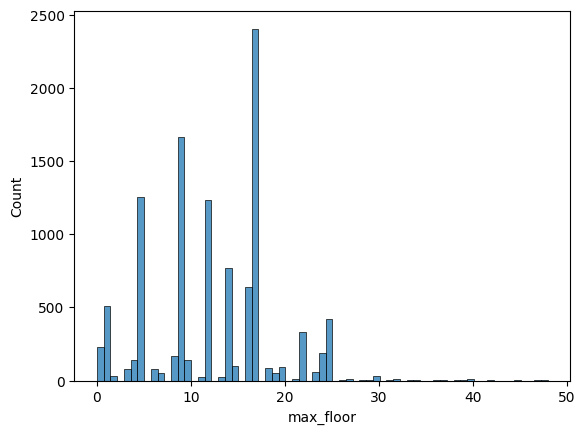

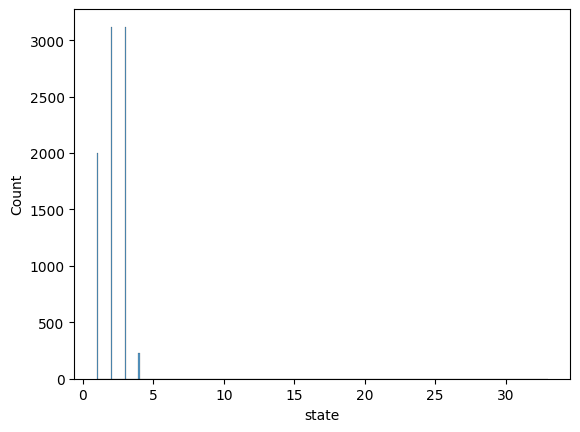

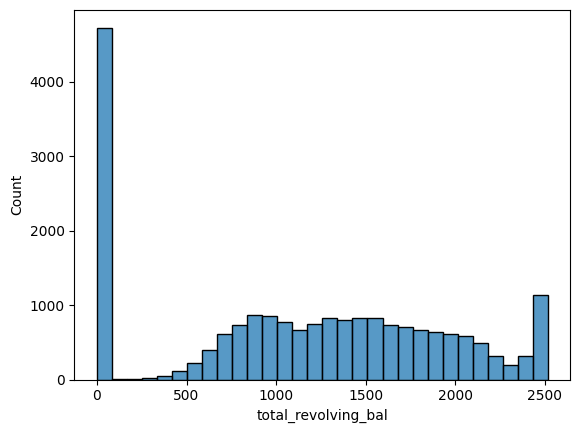

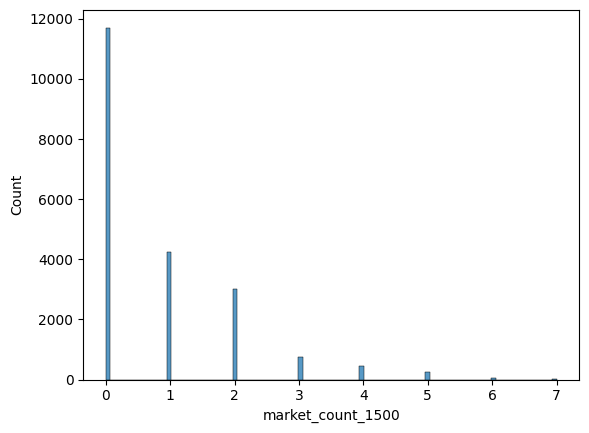

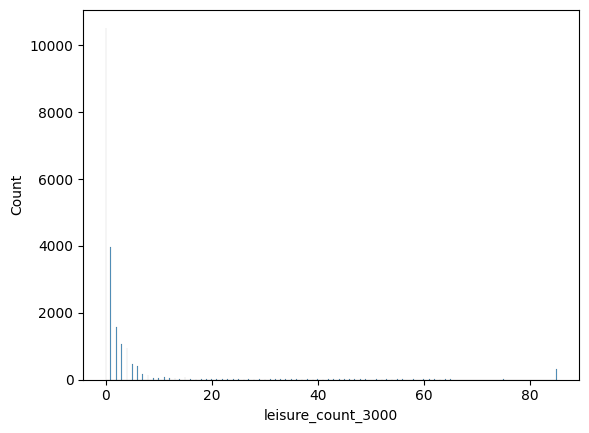

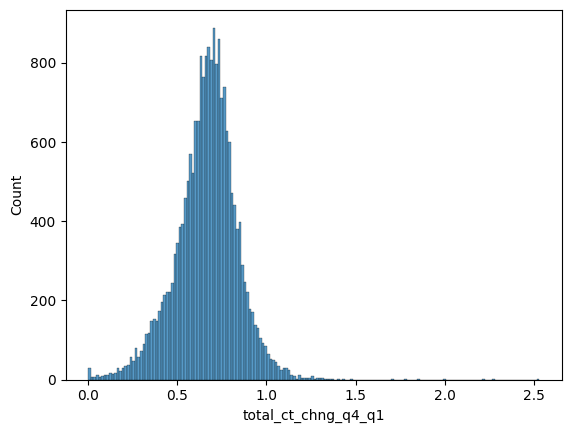

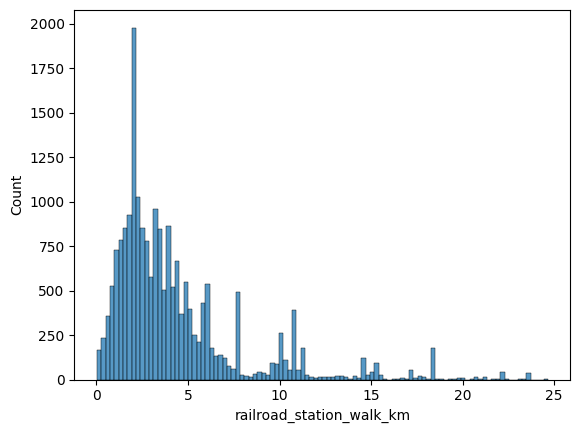

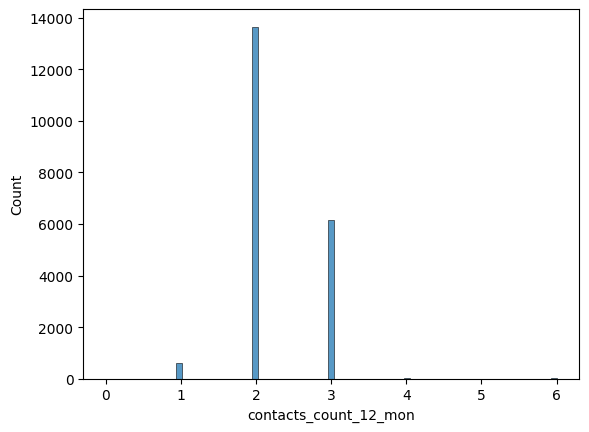

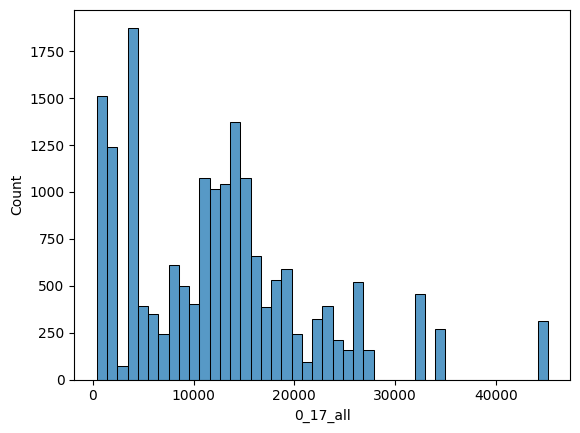

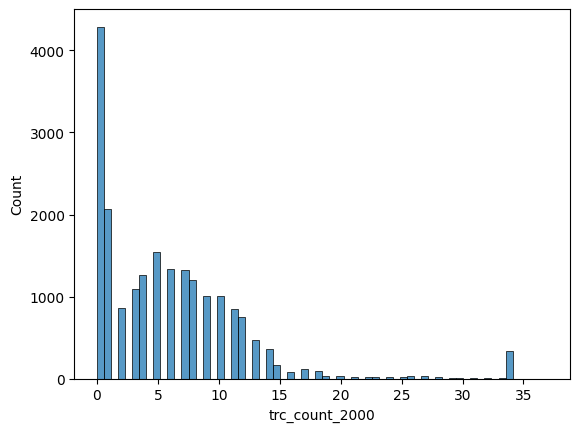

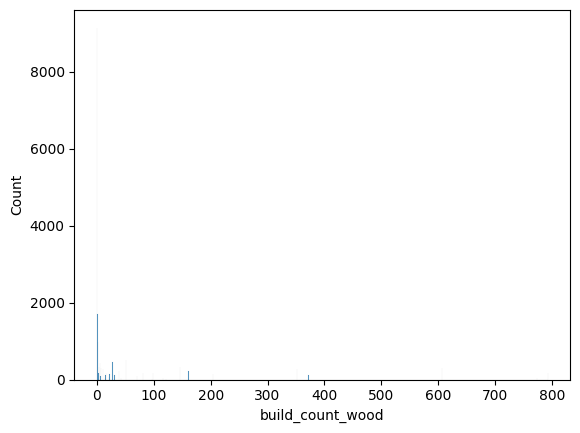

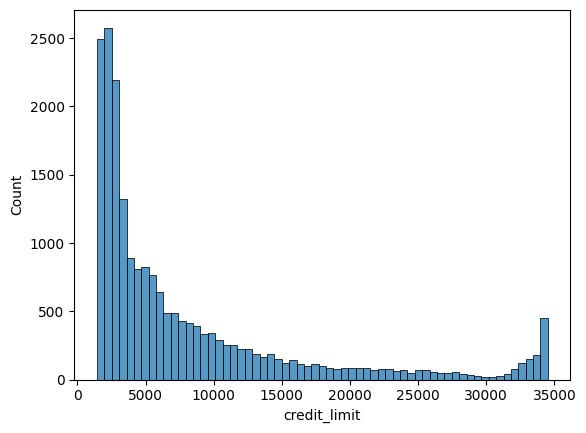

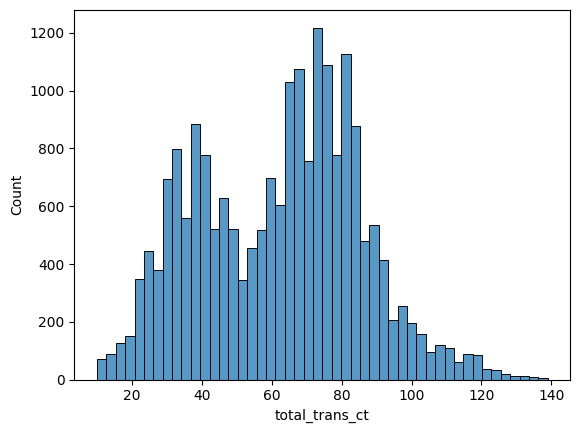

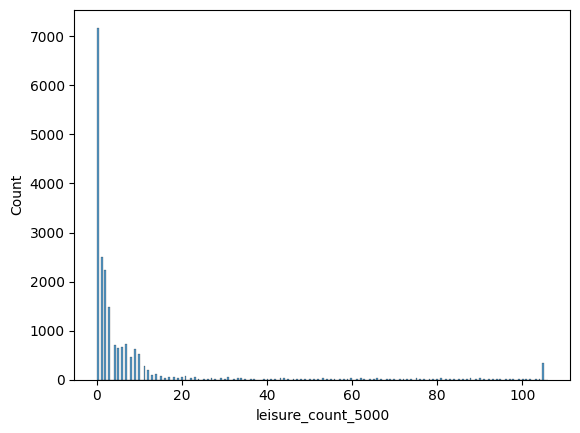

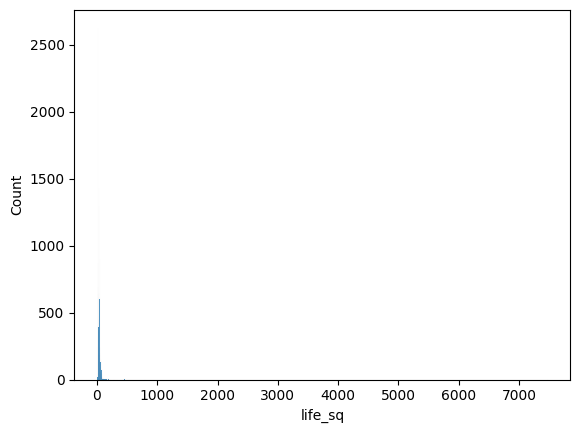

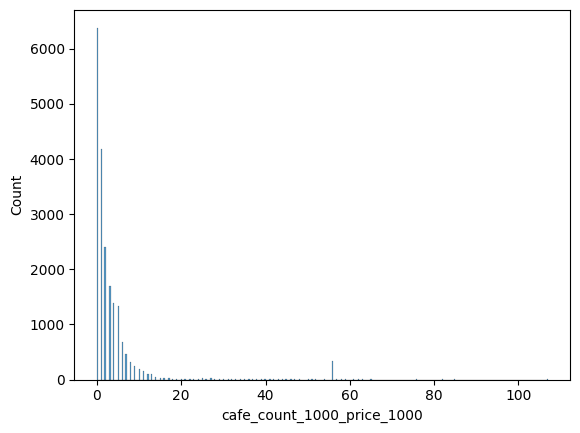

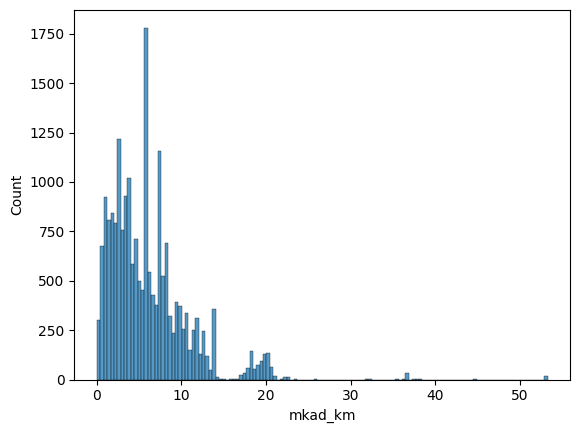

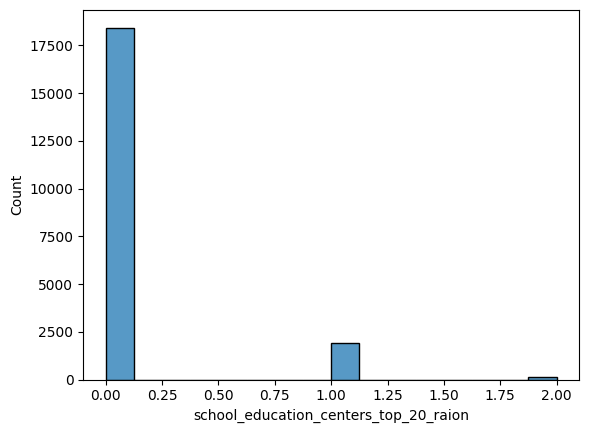

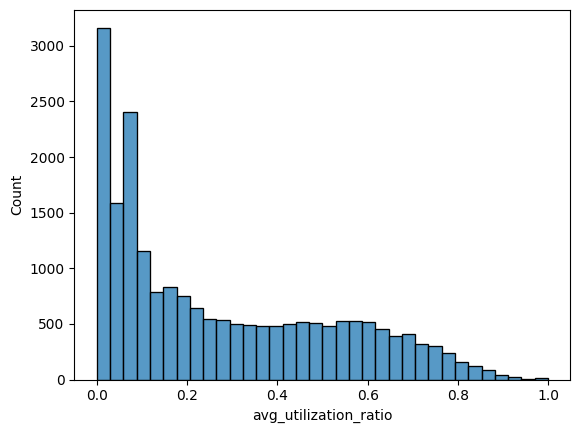

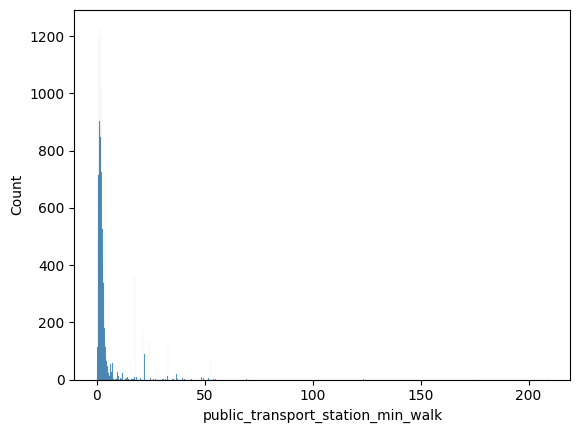

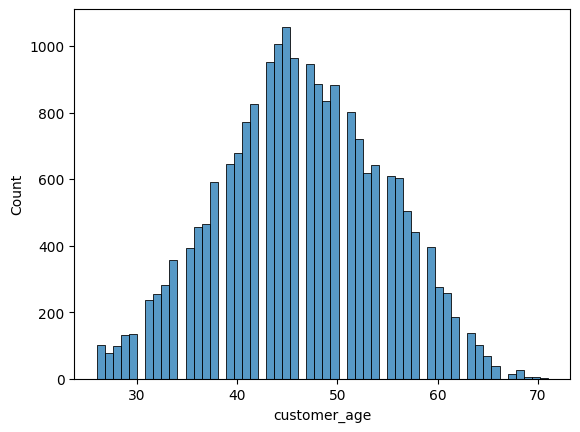

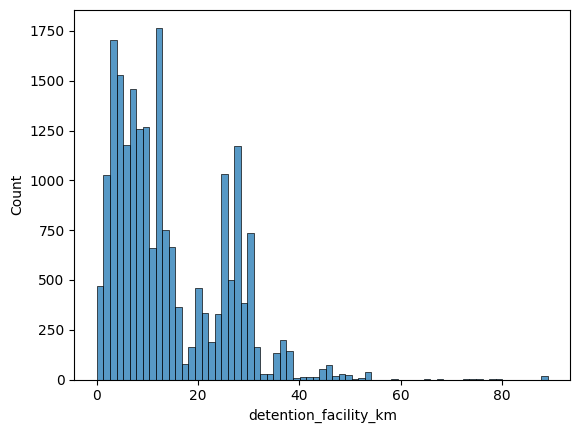

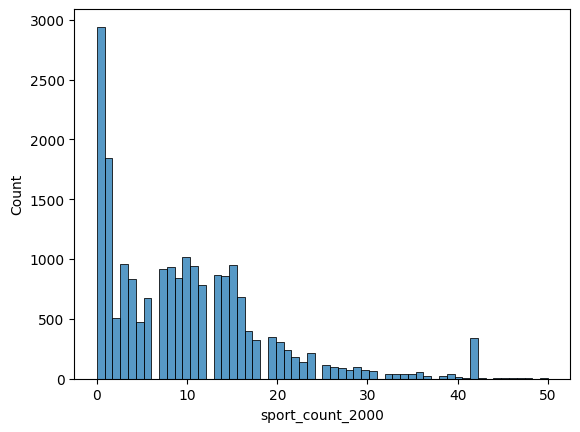

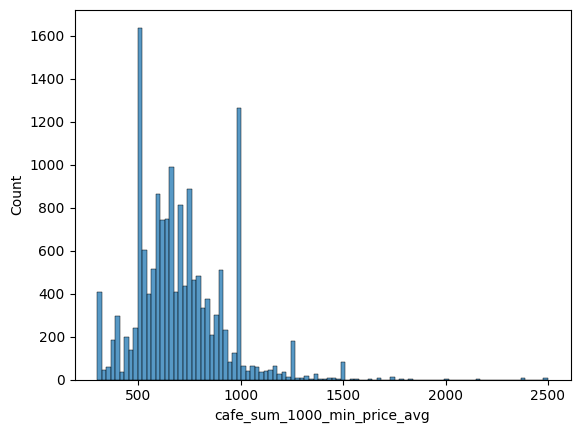

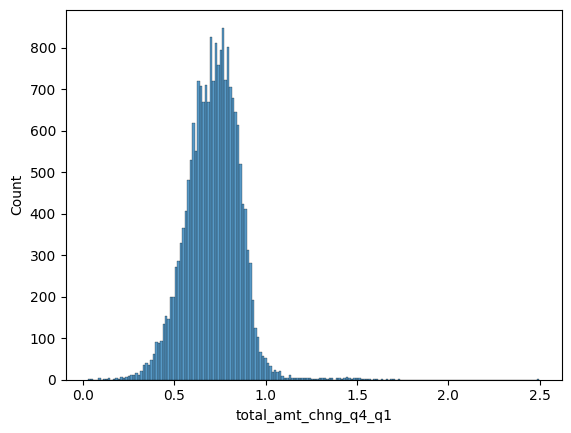

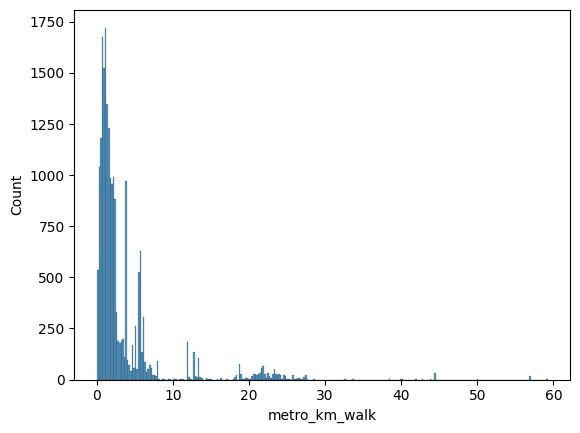

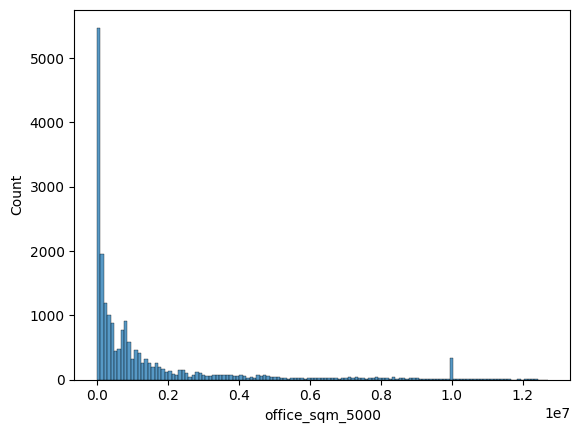

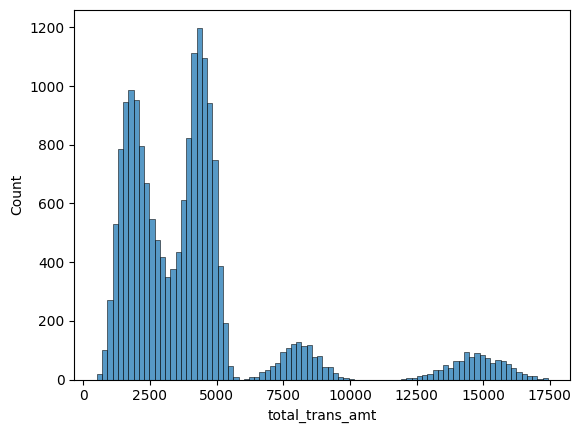

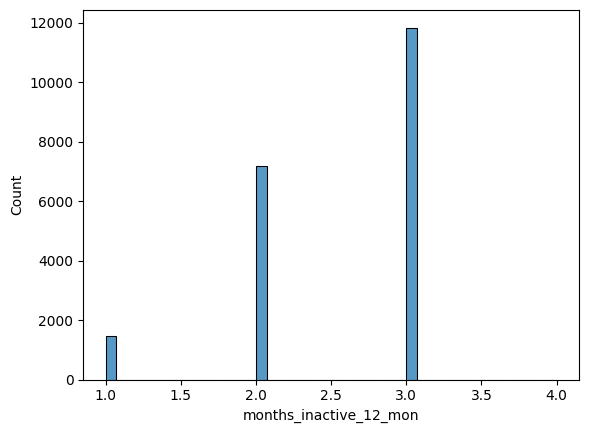

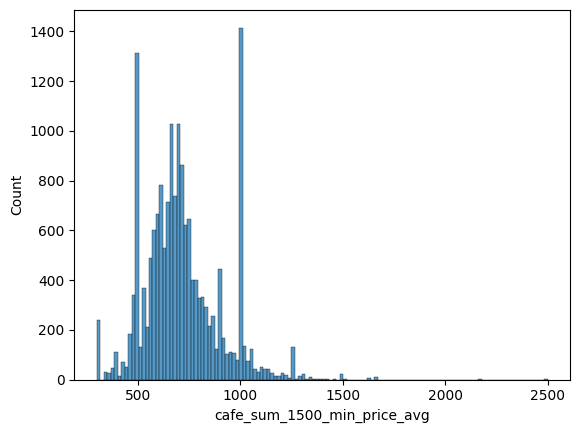

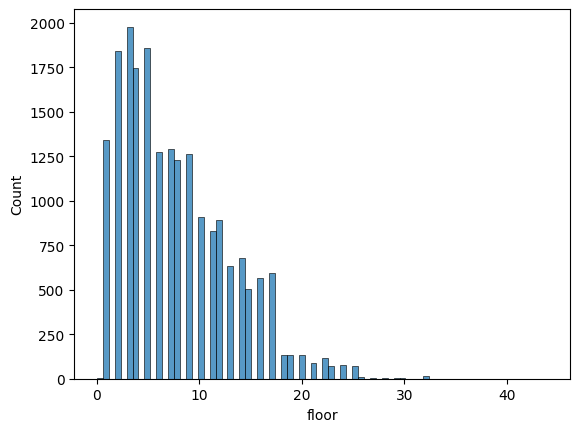

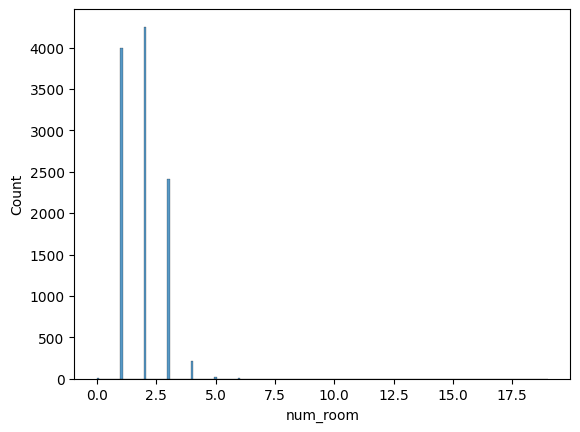

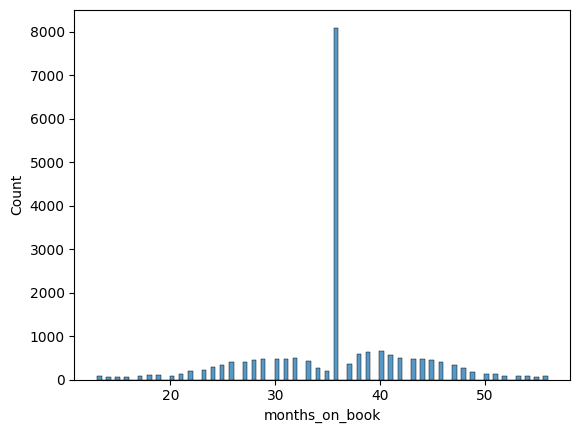

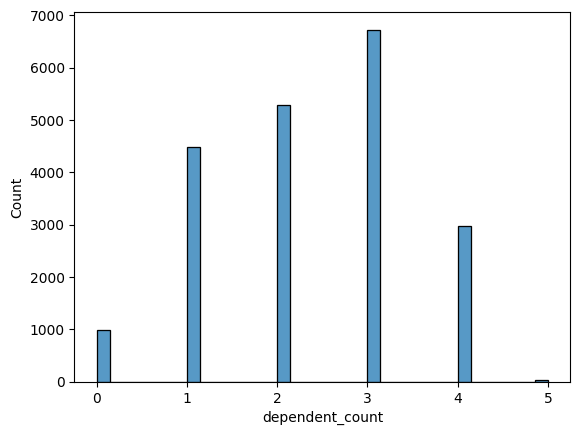

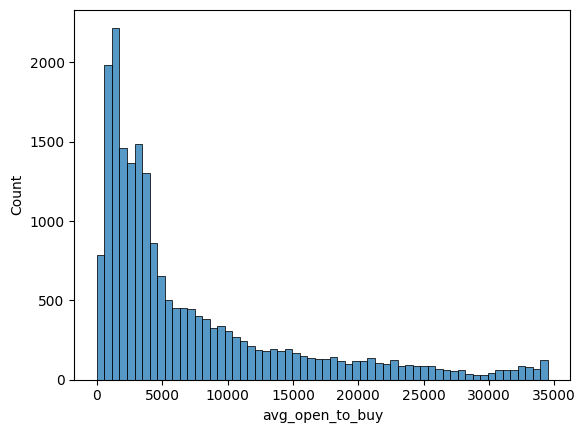

In [ ]:
#histogram to undestand the distribution of the data
import warnings
warnings.filterwarnings('ignore')

for i in train.select_dtypes(include = 'number').columns:
  sns.histplot(data = train, x = i)
  plt.xlabel
  plt.show()



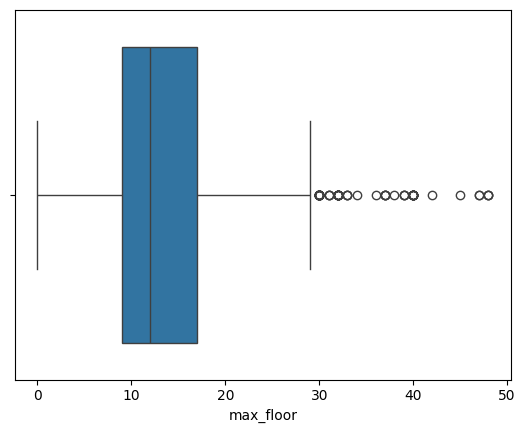

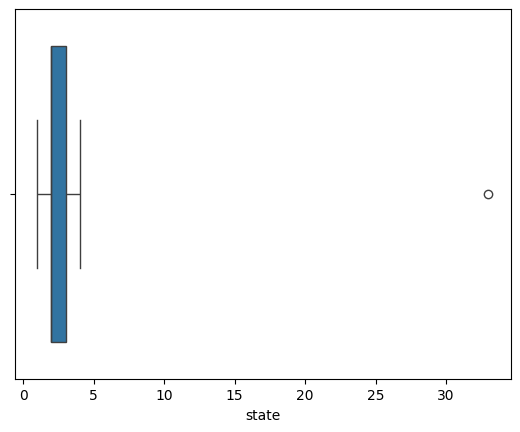

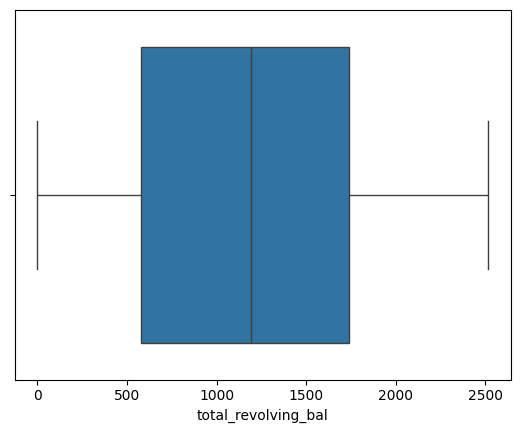

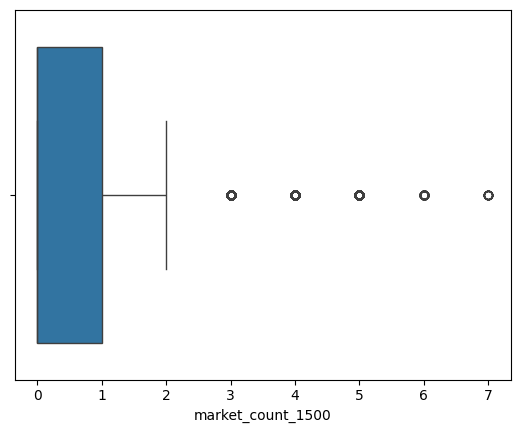

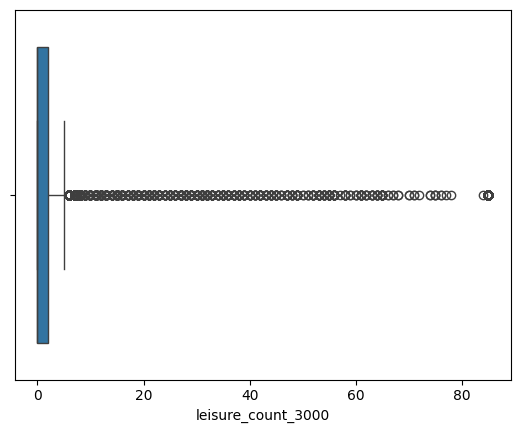

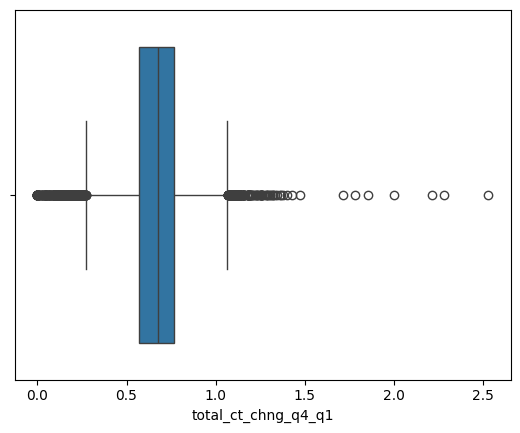

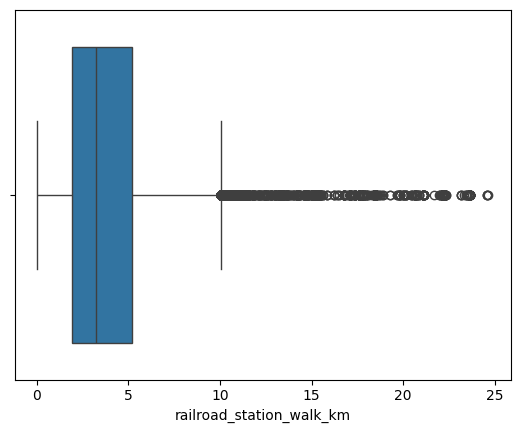

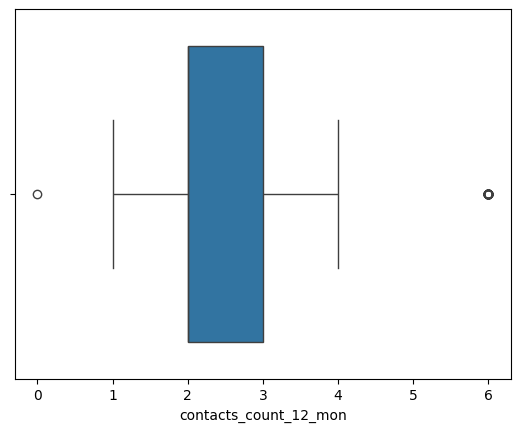

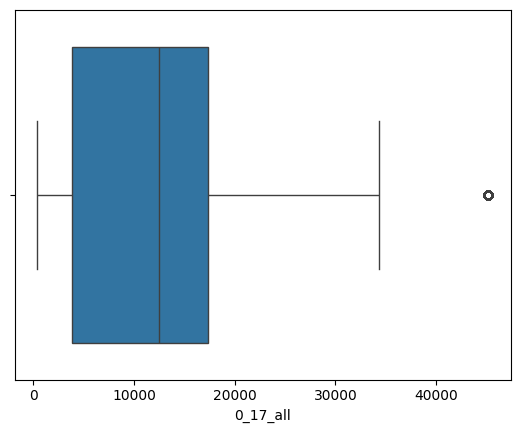

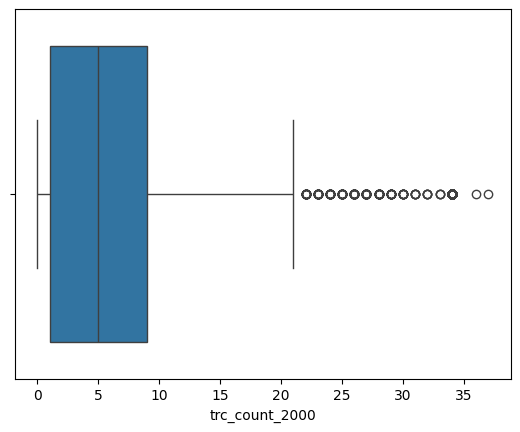

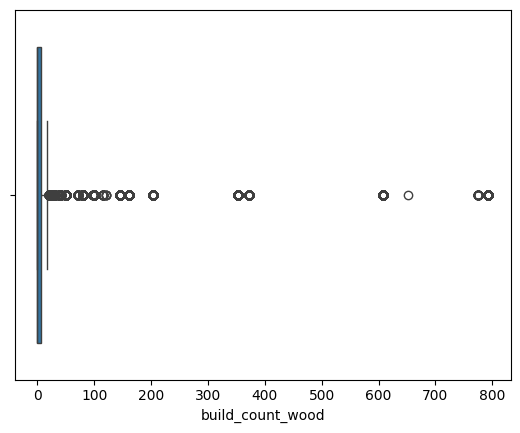

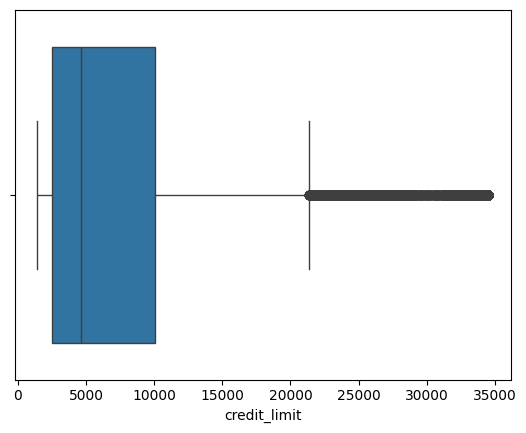

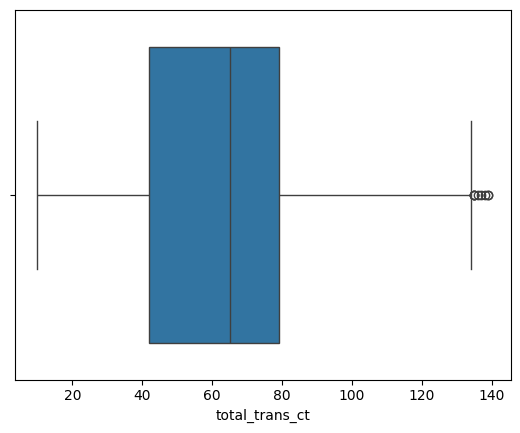

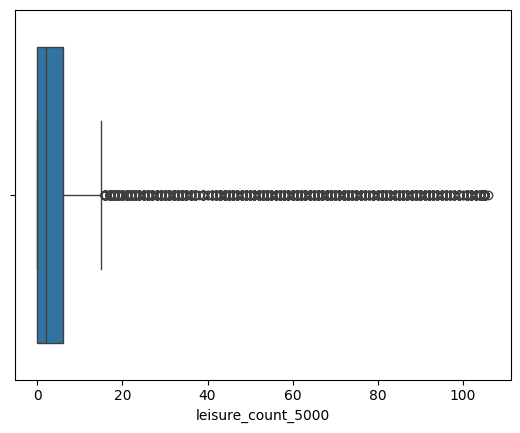

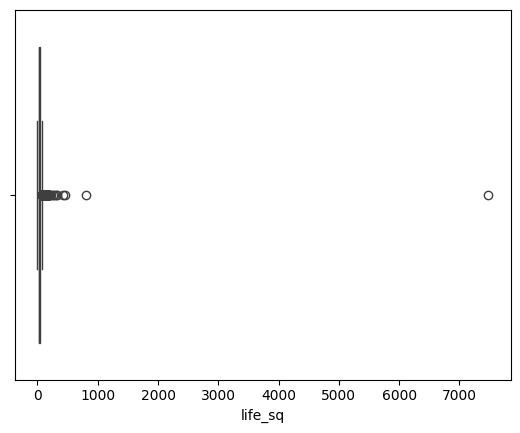

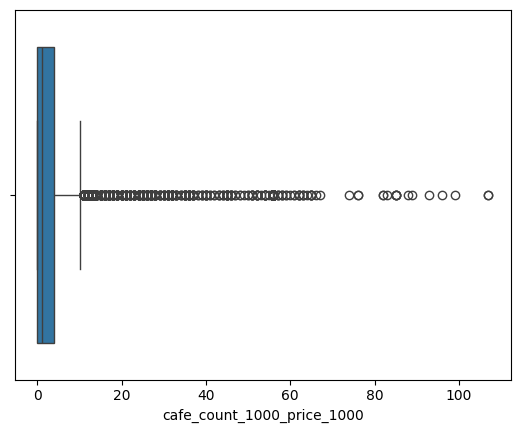

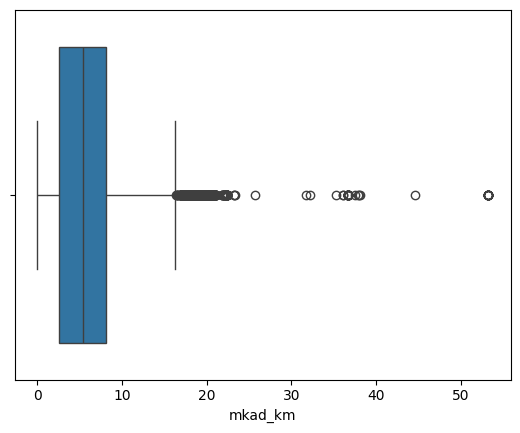

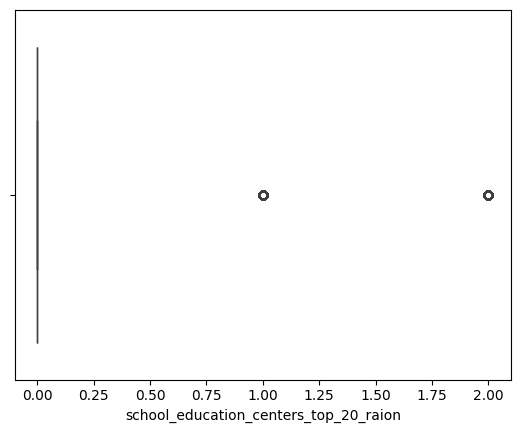

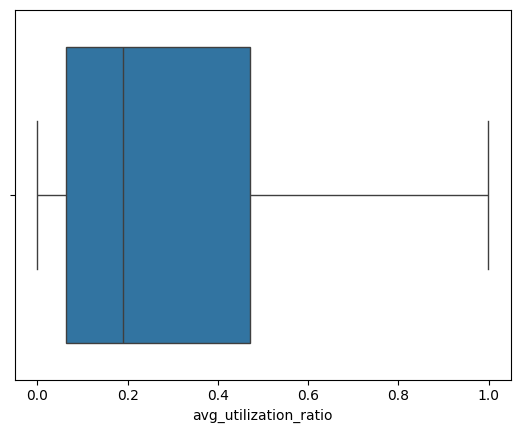

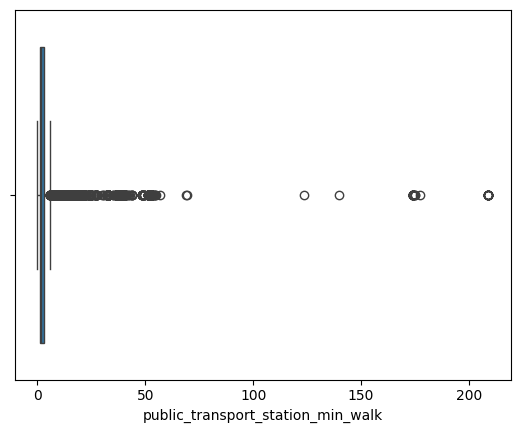

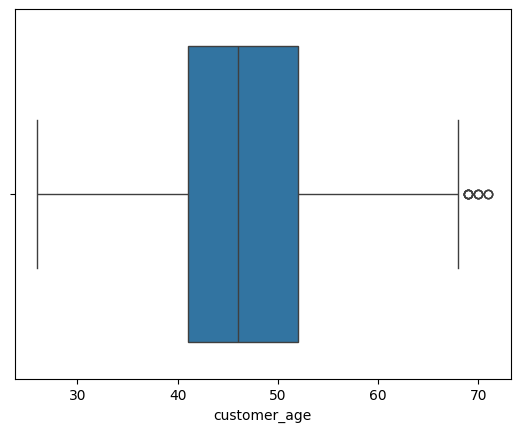

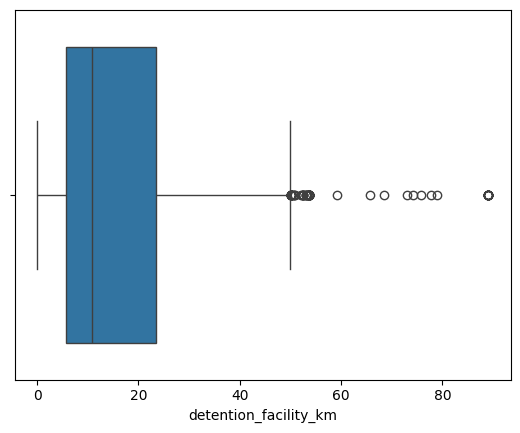

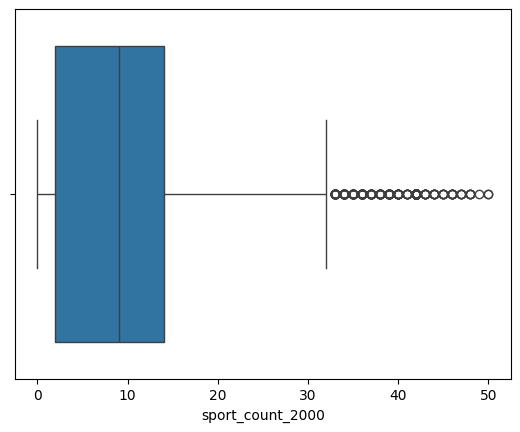

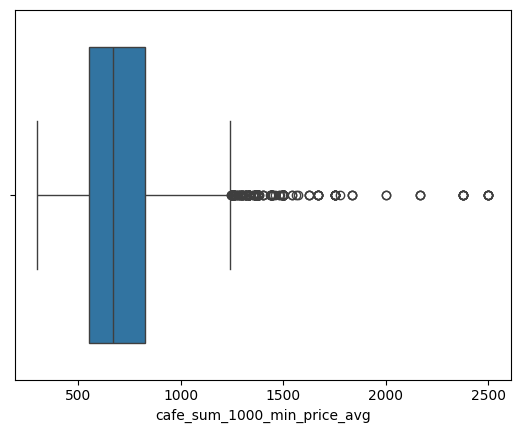

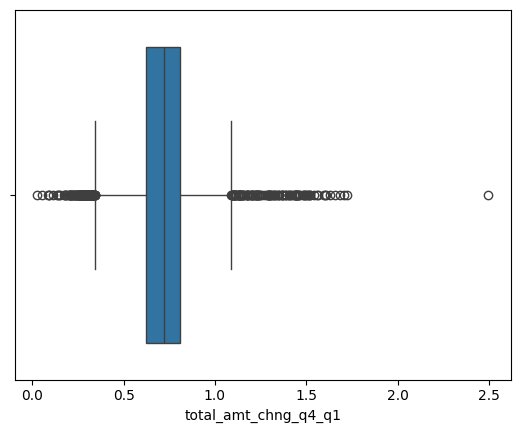

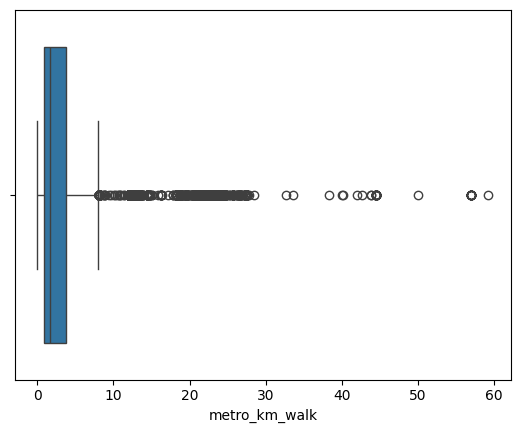

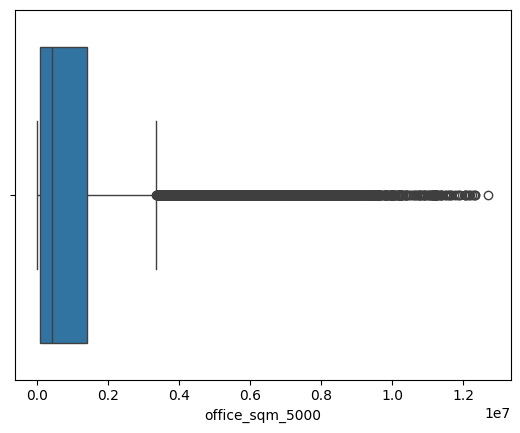

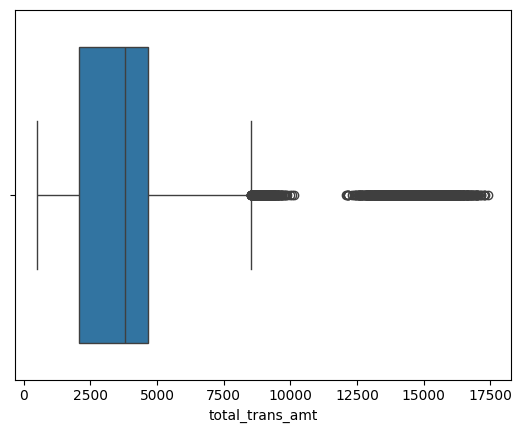

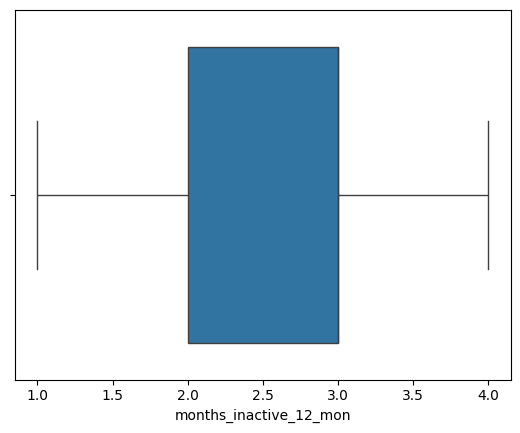

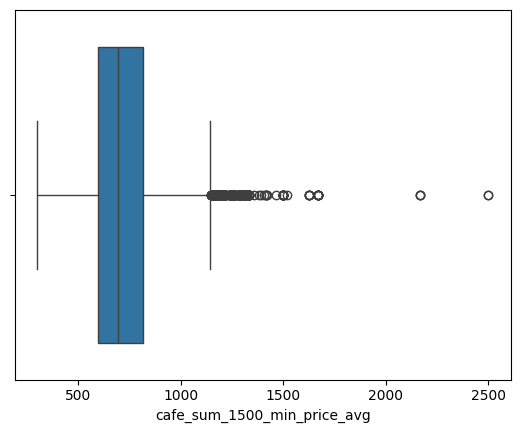

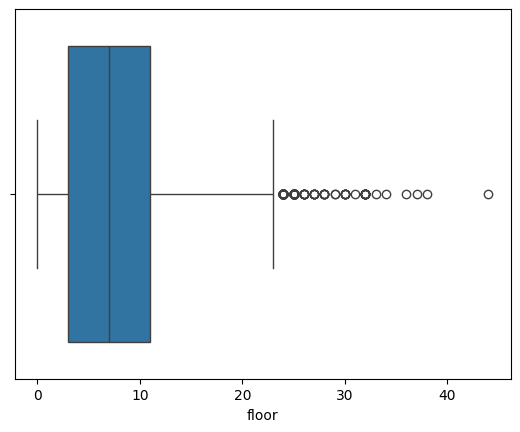

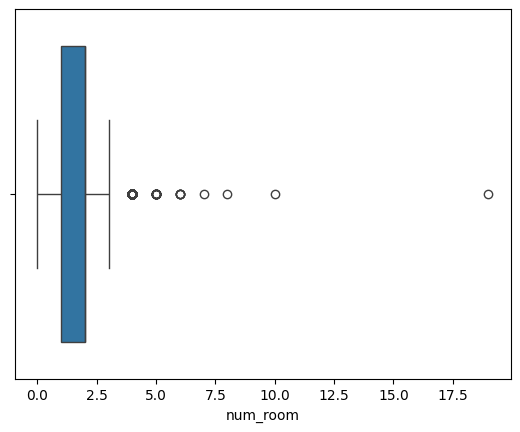

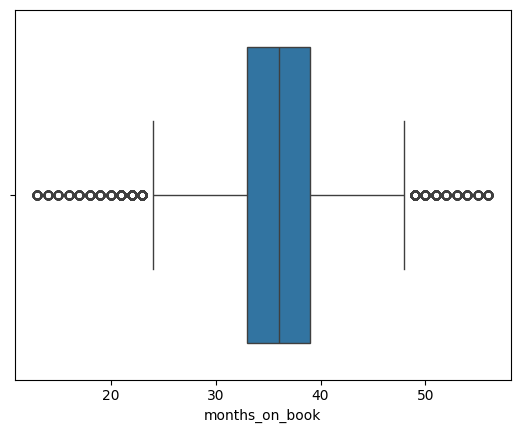

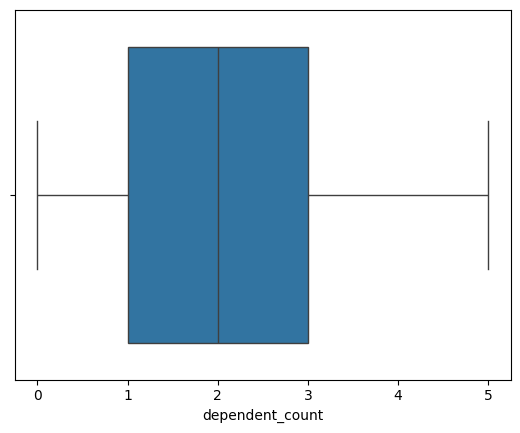

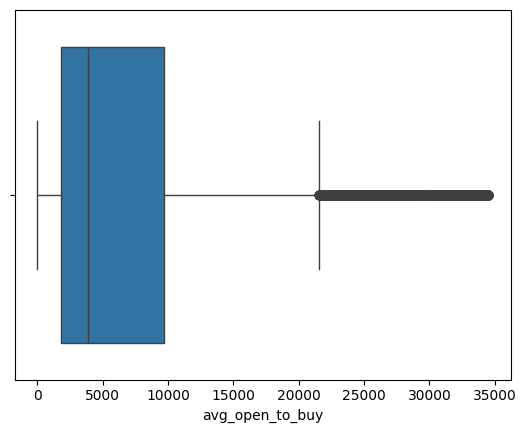

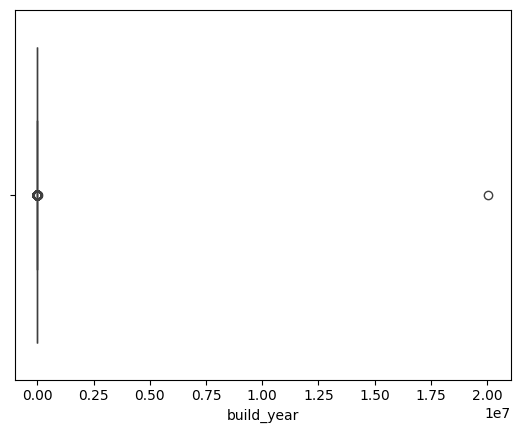

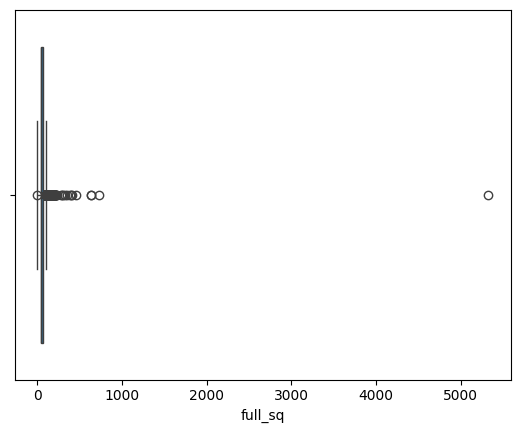

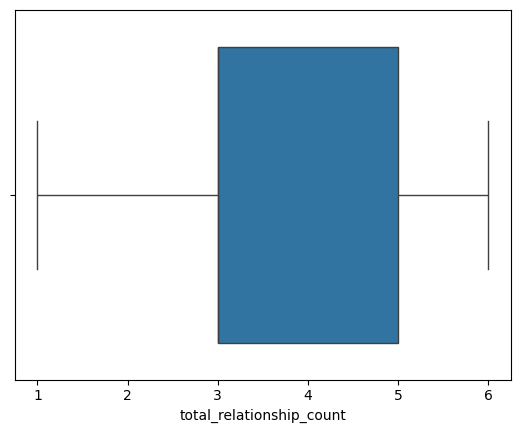

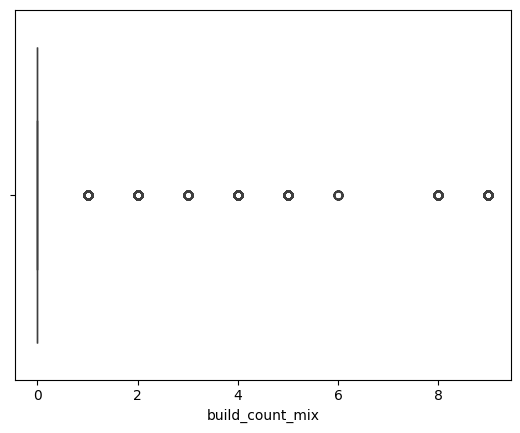

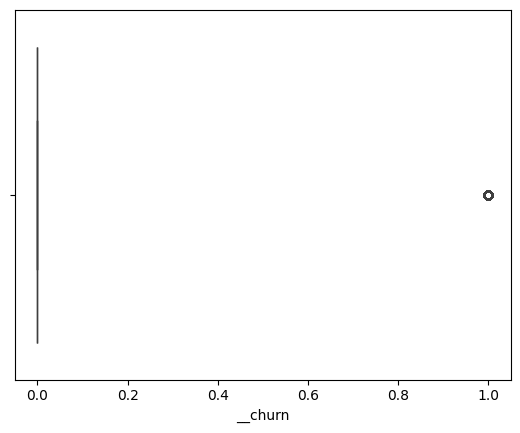

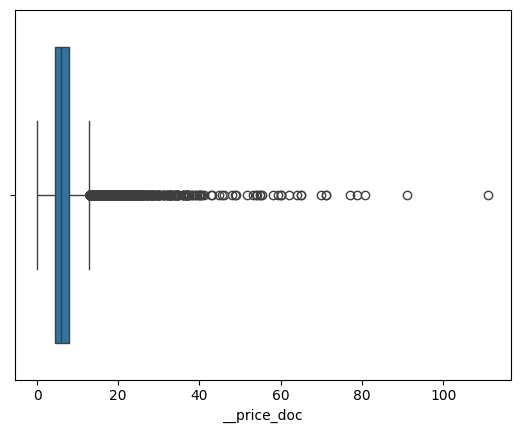

In [ ]:
#checking for outliers using boxplots
for i in train.select_dtypes(include = 'number').columns:
  sns.boxplot(data = train, x = i)
  plt.xlabel
  plt.show()


2.1 Dealing with missing values

In [ ]:
#get the percentage of missing values per column
train.isnull().sum().sort_values(ascending = False)/train.shape[0]*100

,0
state,58.653518
build_year,56.544451
num_room,46.731436
max_floor,46.731436
cafe_sum_1000_min_price_avg,22.438119
life_sq,20.470634
build_count_mix,14.953864
build_count_wood,14.953864
cafe_sum_1500_min_price_avg,14.636528
total_trans_amt,11.731680


In [7]:
test.isnull().sum().sort_values(ascending = False)/train.shape[0]*100

,0
total_trans_amt,44.832300
0_17_all,44.832300
life_sq,9.832544
build_year,9.100229
build_count_mix,8.724308
build_count_wood,8.724308
cafe_sum_1000_min_price_avg,8.675487
state,6.908168
cafe_sum_1500_min_price_avg,5.419128
railroad_station_walk_km,0.063467


In [28]:
#replacing missing values with the median

for i in ['floor', 'max_floor','0_17_all', 'metro_km_walk', 'railroad_station_walk_km']:
  imputer = SimpleImputer(strategy='median')

# fit instance and transform train_median
  train[f'f_{i}'] = imputer.fit_transform(train[[i]])
  test[f'f_{i}'] = imputer.transform(test[[i]])


In [29]:
#replacing missing values with the mode

#select more columns with missing values
fetures_train = ['state','build_year','num_room','cafe_sum_1000_min_price_avg',
'life_sq','build_count_mix','build_count_wood','cafe_sum_1500_min_price_avg',
'total_trans_amt'	]
features_test = ['state','build_year','num_room','cafe_sum_1000_min_price_avg',
'life_sq','build_count_mix','build_count_wood','cafe_sum_1500_min_price_avg',
'total_trans_amt'	]

#create an imputer for the mode
imputer = SimpleImputer(strategy='most_frequent')

#fit the imputer on the selected training features
for i in fetures_train:
  # Fit the imputer to the train data
  imputer.fit(train[[i]])

#transform the train and test data
  train[f'f_{i}'] = imputer.transform(train[[i]]).ravel()  # Flatten the 2D array to 1D
  test[f'f_{i}'] = imputer.transform(test[[i]]).ravel()

In [6]:
train.isnull().sum().sort_values(ascending = False )

,0
state,12014
build_year,11582
max_floor,9572
num_room,9572
cafe_sum_1000_min_price_avg,4596
life_sq,4193
build_count_wood,3063
build_count_mix,3063
cafe_sum_1500_min_price_avg,2998
0_17_all,2403


In [10]:
test.isnull().sum().sort_values(ascending = False )

,0
total_trans_amt,9183
0_17_all,9183
life_sq,2014
build_year,1864
build_count_mix,1787
build_count_wood,1787
cafe_sum_1000_min_price_avg,1777
state,1415
cafe_sum_1500_min_price_avg,1110
railroad_station_walk_km,13


*All empty cells have been filled in*

**2.2 Transforming categorical data into numberic**

In [ ]:
#check all object variables
train.select_dtypes(include = 'object').T

,0,1,2,3,4,5,6,7,8,9,...,20473,20474,20475,20476,20477,20478,20479,20480,20481,20482
marital_status,Single,Married,Married,Married,Married,Single,Married,Married,Single,Married,...,Married,Married,Single,Single,Married,Married,Married,Married,Single,Single
big_market_raion,no,no,no,no,no,no,no,no,no,no,...,no,no,no,yes,no,no,no,no,no,yes
water_1line,no,no,no,no,no,no,no,no,no,no,...,no,no,no,yes,no,yes,no,no,no,no
culture_objects_top_25,no,yes,no,no,no,no,no,no,no,no,...,no,no,no,no,no,no,no,no,no,no
product_type,Investment,Investment,Investment,Investment,Investment,Investment,Investment,Investment,Investment,Investment,...,Investment,Investment,OwnerOccupier,OwnerOccupier,Investment,Investment,Investment,Investment,Investment,Investment
big_road1_1line,no,no,no,no,no,no,no,no,no,no,...,no,no,no,no,no,no,no,no,no,no
card_category,Blue,Blue,Blue,Blue,Blue,Blue,Blue,Blue,Silver,Blue,...,Blue,Blue,Silver,Blue,Blue,Blue,Blue,Blue,Blue,Blue
income_category,Less than $40K,$40K - $60K,$40K - $60K,$60K - $80K,Less than $40K,Less than $40K,Less than $40K,$60K - $80K,$120K +,$80K - $120K,...,$40K - $60K,$60K - $80K,$120K +,Less than $40K,$60K - $80K,$80K - $120K,$40K - $60K,$60K - $80K,Unknown,Less than $40K
thermal_power_plant_raion,no,no,no,no,no,yes,no,no,no,no,...,no,no,no,no,no,no,no,no,no,no
radiation_raion,no,no,yes,no,yes,yes,no,no,no,yes,...,yes,yes,no,no,no,no,no,yes,no,yes


In [ ]:
#Check values in income category

train['income_category'].unique()

array(['Less than $40K', '$40K - $60K', '$60K - $80K', '$120K +',
       '$80K - $120K', 'Unknown'], dtype=object)

In [ ]:
#Check values  in ecology

train['ecology'].unique()


array(['good', 'excellent', 'poor', 'satisfactory', 'no data'],
      dtype=object)

In [ ]:
#Check values in education_level

test['education_level'].unique()

array(['Graduate', 'High School', 'Unknown'], dtype=object)

In [ ]:
#Check values in card_category
train['card_category'].unique()

array(['Blue', 'Silver', 'Gold'], dtype=object)

*Applying the transformations*

In [14]:
train.shape

(20483, 75)

In [ ]:
#columns with categorical data type
columns_cat = ['marital_status', 'big_market_raion', 'water_1line',
       'culture_objects_top_25', 'product_type', 'big_road1_1line',
       'card_category', 'income_category', 'thermal_power_plant_raion',
       'radiation_raion', 'ecology', 'gender', 'oil_chemistry_raion',
       'nuclear_reactor_raion', 'railroad_1line', 'timestamp',
       'education_level', 'incineration_raion', 'detention_facility_raion',
       'railroad_terminal_raion']

In [30]:
#Target encoding
warnings.filterwarnings('ignore')

columns_to_convert = ['marital_status', 'product_type',  'card_category',
                      'income_category','ecology', 'timestamp',
                      'education_level']

def target_encode(train, test, target):
  # Initialize a dictionary to store encodings
  encodings = {}

  # Iterate over columns to convert
  for col in columns_to_convert:

   # iniciating the target encoder, fit and transform the training data
    encoder = TargetEncoder(cols = [col])
    train[f'f_{col}_target_{target}'] = encoder.fit_transform(
        train[[col]], train[target])

    #transform the tresting data
    test[f'f_{col}_target_{target}'] = encoder.transform(
        train[[col]])

    encodings[col] = encoder
  return train, test, encodings

train, test, churn_encodings = target_encode(train, test , '__churn')
train, test, price_doc_encodings = target_encode(train , test, '__price_doc')

In [31]:
#copy dataset
train_enc = train.copy()
test_enc = test.copy()

In [32]:
#Replace all ordinal binary features Using one_hot encoding
convert_columns = ['big_market_raion','water_1line','culture_objects_top_25',
                     'big_road1_1line','thermal_power_plant_raion',
                     'radiation_raion','gender','oil_chemistry_raion',
'nuclear_reactor_raion','railroad_1line', 'incineration_raion',
'detention_facility_raion', 'railroad_terminal_raion']

# Initialize the OneHotEncoder
onehot = OneHotEncoder(sparse_output=False)

# Loop through each column to apply one-hot encoding
for col in convert_columns:
    # Fit the encoder on the training data for the current column
    onehot.fit(train_enc[[col]])

    # Transform both training and test datasets
    values_train = onehot.transform(train_enc[[col]])
    values_test = onehot.transform(test_enc[[col]])

    # Create new column names with the prefix "f_"
    list_names = [f'f_{col}_{cat}' for cat in onehot.categories_[0]]

    # Add the one-hot encoded columns to the training and test DataFrames
    train_enc[list_names] = values_train
    test_enc[list_names] = values_test

    # Optionally, drop the original column if you no longer need it
    train_enc.drop(columns=[col], inplace=True)
    test_enc.drop(columns=[col], inplace=True)

In [33]:
train_enc.shape, test_enc.shape

((20483, 102), (9183, 101))

In [34]:
train_enc.head(20).T

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19
max_floor,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
state,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
marital_status,Single,Married,Married,Married,Married,Single,Married,Married,Single,Married,Married,Single,Married,Married,Married,Married,Married,Married,Single,Single
total_revolving_bal,1906,12,2153,1806,753,658,0,17,1421,1706,2086,0,1962,1356,1801,1083,1686,1439,1559,59
market_count_1500,1,0,5,2,2,0,1,1,2,0,1,0,0,0,3,4,1,1,1,3
leisure_count_3000,0,6,0,0,40,2,8,0,1,1,0,0,2,10,4,0,2,8,0,2
total_ct_chng_q4_q1,0.694,0.693,0.831,0.638,0.902,0.671,0.475,0.734,0.804,1.049,0.848,0.251,0.839,0.59,1.187,0.917,0.549,0.279,0.738,0.721
railroad_station_walk_km,5.419893,3.411993,1.277658,4.291432,0.85396,0.375312,2.603671,4.309575,1.540958,2.522422,3.43212,4.978186,0.635649,1.254206,0.904529,3.681023,2.393325,2.400835,3.788198,3.774845
contacts_count_12_mon,2,2,2,2,2,2,2,2,2,2,2,3,2,2,2,2,2,2,2,2
0_17_all,23603.0,17700.0,14884.0,32063.0,15237.0,5866.0,6510.0,23603.0,15510.0,22071.0,15057.0,13390.0,22071.0,16727.0,12229.0,45170.0,18245.0,11749.0,15057.0,18912.0


In [35]:
#copy dataset
transform_train = train_enc.copy()
transform_test = test_enc.copy()

In [36]:
#check the shape of the data
transform_train.shape, transform_test.shape

((20483, 102), (9183, 101))

**3. Handling outliers (normalization) **

In [37]:
# Identify features with outliers based on IQR
features_train = [col for col in transform_train.select_dtypes(include = ['int64', 'float64']) if col not in['__churn', '__price_doc']]
features_test= [col for col in transform_test.select_dtypes(include = ['int64', 'float64']) if col not in['Unnamed: 0']]


def identify_outlier_features(transform_train):
    outlier_features = []
    for col in features_train:
        Q1 = transform_train[col].quantile(0.25)
        Q3 = transform_train[col].quantile(0.75)
        IQR = Q3 - Q1
        # Define outlier bounds
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        # Check if there are any outliers
        if (transform_train[col] < lower_bound).any() or (transform_train[col] > upper_bound).any():
            outlier_features.append(col)
    return outlier_features




In [38]:
# Identify features with outliers
features_with_outliers = identify_outlier_features(transform_train)
print("Features with outliers:", features_with_outliers)

Features with outliers: ['max_floor', 'state', 'market_count_1500', 'leisure_count_3000', 'total_ct_chng_q4_q1', 'railroad_station_walk_km', 'contacts_count_12_mon', '0_17_all', 'trc_count_2000', 'build_count_wood', 'credit_limit', 'total_trans_ct', 'leisure_count_5000', 'life_sq', 'cafe_count_1000_price_1000', 'mkad_km', 'school_education_centers_top_20_raion', 'public_transport_station_min_walk', 'customer_age', 'detention_facility_km', 'sport_count_2000', 'cafe_sum_1000_min_price_avg', 'total_amt_chng_q4_q1', 'metro_km_walk', 'office_sqm_5000', 'total_trans_amt', 'cafe_sum_1500_min_price_avg', 'floor', 'num_room', 'months_on_book', 'avg_open_to_buy', 'build_year', 'full_sq', 'build_count_mix', 'f_floor', 'f_max_floor', 'f_0_17_all', 'f_metro_km_walk', 'f_railroad_station_walk_km', 'f_state', 'f_build_year', 'f_num_room', 'f_cafe_sum_1000_min_price_avg', 'f_life_sq', 'f_build_count_mix', 'f_build_count_wood', 'f_cafe_sum_1500_min_price_avg', 'f_total_trans_amt', 'f_card_category_targ

In [40]:
#Select all old features
columns_old = ['marital_status', 'big_market_raion', 'water_1line',
       'culture_objects_top_25', 'product_type', 'big_road1_1line',
       'card_category', 'income_category', 'thermal_power_plant_raion',
       'radiation_raion', 'ecology', 'gender', 'oil_chemistry_raion',
       'nuclear_reactor_raion', 'railroad_1line', 'timestamp',
       'education_level', 'incineration_raion', 'detention_facility_raion',
       'railroad_terminal_raion', 'state','build_year','num_room','cafe_sum_1000_min_price_avg',
'life_sq','build_count_mix','build_count_wood','cafe_sum_1500_min_price_avg',
'total_trans_amt', 'floor', 'max_floor','0_17_all', 'metro_km_walk', 'railroad_station_walk_km'	]

In [41]:
#finding all old features without the f_ to normalize
all_old_features = [col for col in transform_train.select_dtypes(
    include = ['int64', 'float64']) if not col.startswith('f_')
and col not in columns_old and col not in ['__churn',
 '__price_doc']]

all_old_features

['total_revolving_bal',
 'market_count_1500',
 'leisure_count_3000',
 'total_ct_chng_q4_q1',
 'contacts_count_12_mon',
 'trc_count_2000',
 'credit_limit',
 'total_trans_ct',
 'leisure_count_5000',
 'cafe_count_1000_price_1000',
 'mkad_km',
 'school_education_centers_top_20_raion',
 'avg_utilization_ratio',
 'public_transport_station_min_walk',
 'customer_age',
 'detention_facility_km',
 'sport_count_2000',
 'total_amt_chng_q4_q1',
 'office_sqm_5000',
 'months_inactive_12_mon',
 'months_on_book',
 'dependent_count',
 'avg_open_to_buy',
 'full_sq',
 'total_relationship_count']

In [50]:
#select all new features (with f_)
all_new_features_total = [col for col in transform_train.columns if col.startswith('f_')]
all_new_features_total

['f_floor',
 'f_max_floor',
 'f_0_17_all',
 'f_metro_km_walk',
 'f_railroad_station_walk_km',
 'f_state',
 'f_build_year',
 'f_num_room',
 'f_cafe_sum_1000_min_price_avg',
 'f_life_sq',
 'f_build_count_mix',
 'f_build_count_wood',
 'f_cafe_sum_1500_min_price_avg',
 'f_total_trans_amt',
 'f_marital_status_target___churn',
 'f_product_type_target___churn',
 'f_card_category_target___churn',
 'f_income_category_target___churn',
 'f_ecology_target___churn',
 'f_timestamp_target___churn',
 'f_education_level_target___churn',
 'f_marital_status_target___price_doc',
 'f_product_type_target___price_doc',
 'f_card_category_target___price_doc',
 'f_income_category_target___price_doc',
 'f_ecology_target___price_doc',
 'f_timestamp_target___price_doc',
 'f_education_level_target___price_doc',
 'f_big_market_raion_no',
 'f_big_market_raion_yes',
 'f_water_1line_no',
 'f_water_1line_yes',
 'f_culture_objects_top_25_no',
 'f_culture_objects_top_25_yes',
 'f_big_road1_1line_no',
 'f_big_road1_1line_y

In [45]:
#exclude binary features with one_hot encoding to normalize
all_new_features = ['f_floor',
 'f_max_floor',
 'f_0_17_all',
 'f_metro_km_walk',
 'f_railroad_station_walk_km',
 'f_state',
 'f_build_year',
 'f_num_room',
 'f_cafe_sum_1000_min_price_avg',
 'f_life_sq',
 'f_build_count_mix',
 'f_build_count_wood',
 'f_cafe_sum_1500_min_price_avg',
 'f_total_trans_amt',
 'f_marital_status_target___churn',
 'f_product_type_target___churn',
 'f_card_category_target___churn',
 'f_income_category_target___churn',
 'f_ecology_target___churn',
 'f_timestamp_target___churn',
 'f_education_level_target___churn',
 'f_marital_status_target___price_doc',
 'f_product_type_target___price_doc',
 'f_card_category_target___price_doc',
 'f_income_category_target___price_doc',
 'f_ecology_target___price_doc',
 'f_timestamp_target___price_doc',
 'f_education_level_target___price_doc']

In [46]:
#use quantile transformer to deal with outliers
from sklearn.preprocessing import QuantileTransformer

#for old feartures

# Initialize the QuantileTransformer
quantile = QuantileTransformer(output_distribution='normal')

# Loop through the features to fit and transform
for feature in all_old_features:
    # Fit the transformer on the training data
    quantile.fit(transform_train[[feature]])

    # Transform both train and test datasets
    transform_train[f'f_1_{feature}'] = quantile.transform(transform_train[[feature]])
    transform_test[f'f_1_{feature}'] = quantile.transform(transform_test[[feature]])

In [47]:
#using quantile transformer on transformed features (features with f_)

# Initialize the QuantileTransformer
quantile = QuantileTransformer(output_distribution='normal')

# Loop through the features to fit and transform
for feature in all_new_features:
    # Fit the transformer on the training data
    quantile.fit(transform_train[[feature]])

    # Transform both train and test datasets
    transform_train[feature] = quantile.transform(transform_train[[feature]])
    transform_test[feature] = quantile.transform(transform_test[[feature]])

In [48]:
#print all transforemed features
for col in transform_train:
  if col.startswith('f_'):
    print(col)

f_floor
f_max_floor
f_0_17_all
f_metro_km_walk
f_railroad_station_walk_km
f_state
f_build_year
f_num_room
f_cafe_sum_1000_min_price_avg
f_life_sq
f_build_count_mix
f_build_count_wood
f_cafe_sum_1500_min_price_avg
f_total_trans_amt
f_marital_status_target___churn
f_product_type_target___churn
f_card_category_target___churn
f_income_category_target___churn
f_ecology_target___churn
f_timestamp_target___churn
f_education_level_target___churn
f_marital_status_target___price_doc
f_product_type_target___price_doc
f_card_category_target___price_doc
f_income_category_target___price_doc
f_ecology_target___price_doc
f_timestamp_target___price_doc
f_education_level_target___price_doc
f_big_market_raion_no
f_big_market_raion_yes
f_water_1line_no
f_water_1line_yes
f_culture_objects_top_25_no
f_culture_objects_top_25_yes
f_big_road1_1line_no
f_big_road1_1line_yes
f_thermal_power_plant_raion_no
f_thermal_power_plant_raion_yes
f_radiation_raion_no
f_radiation_raion_yes
f_gender_F
f_gender_M
f_oil_chemi

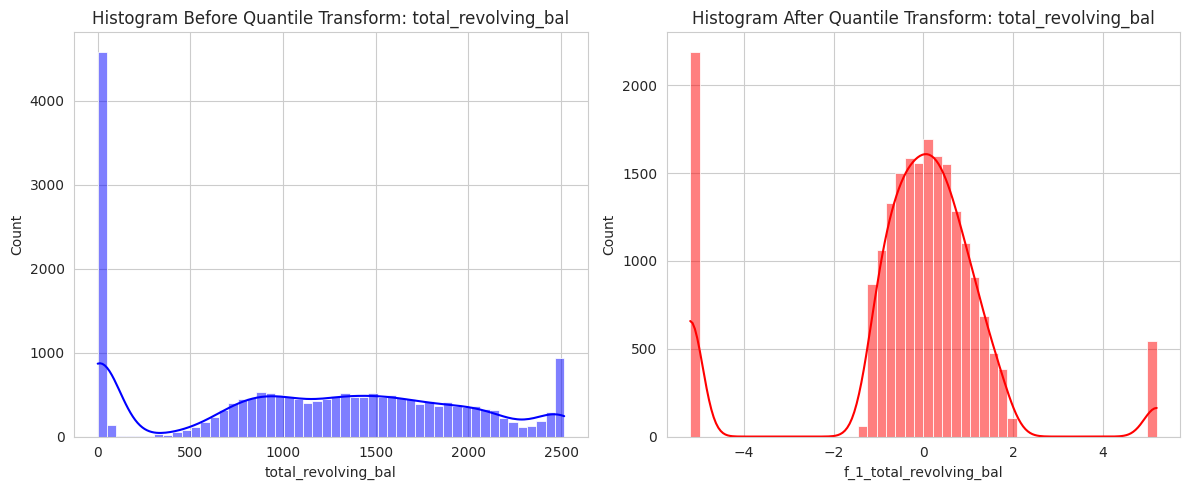

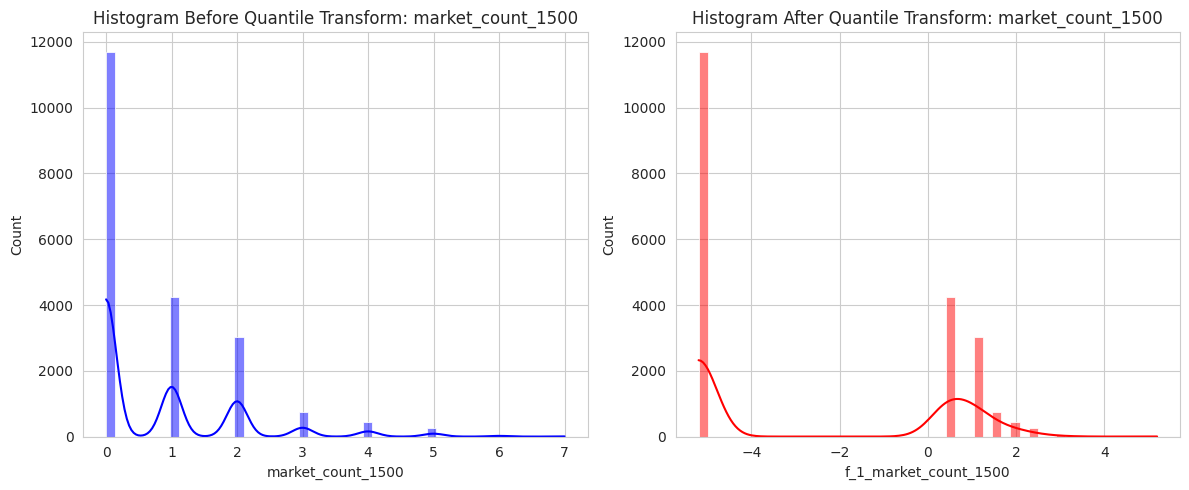

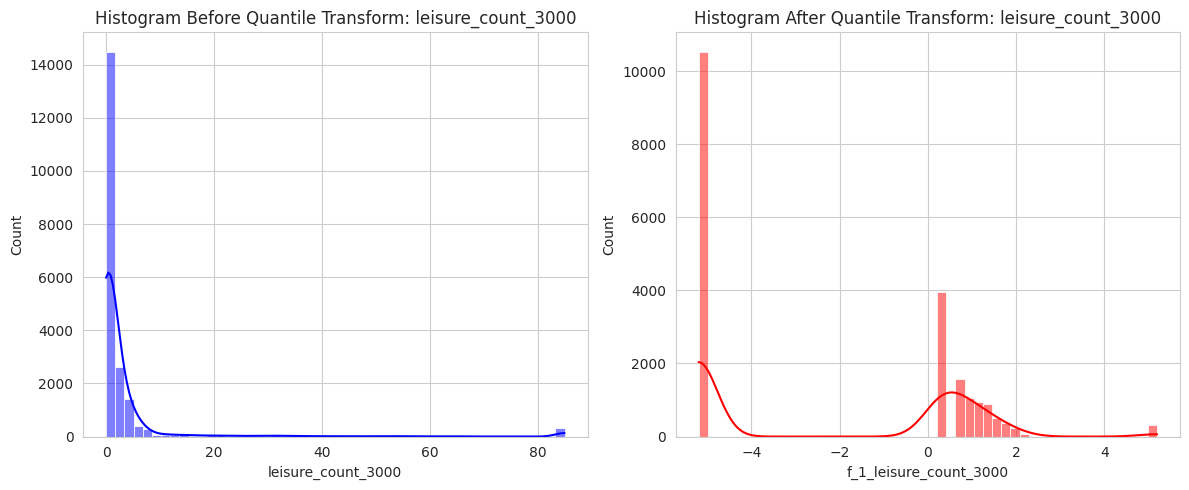

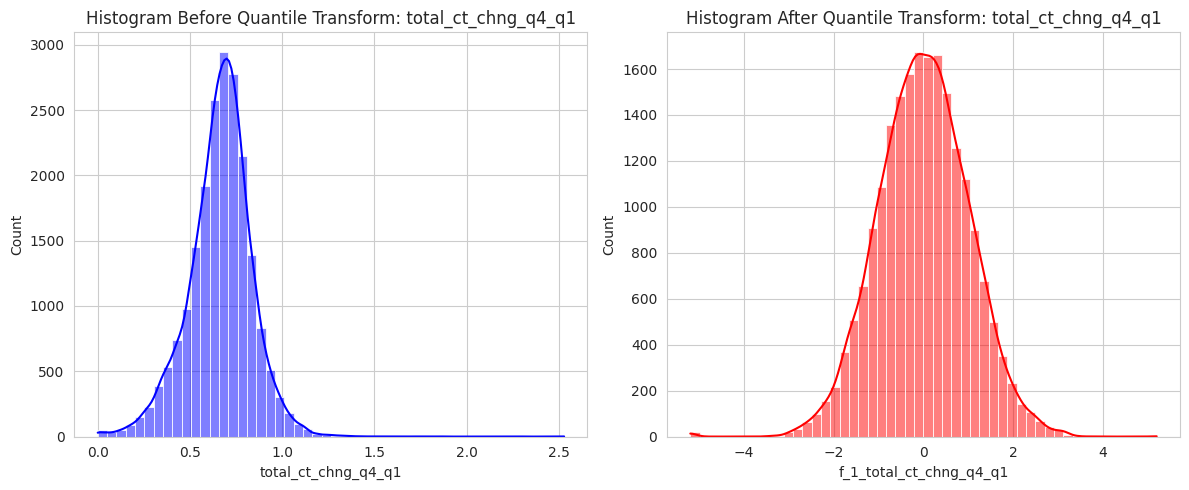

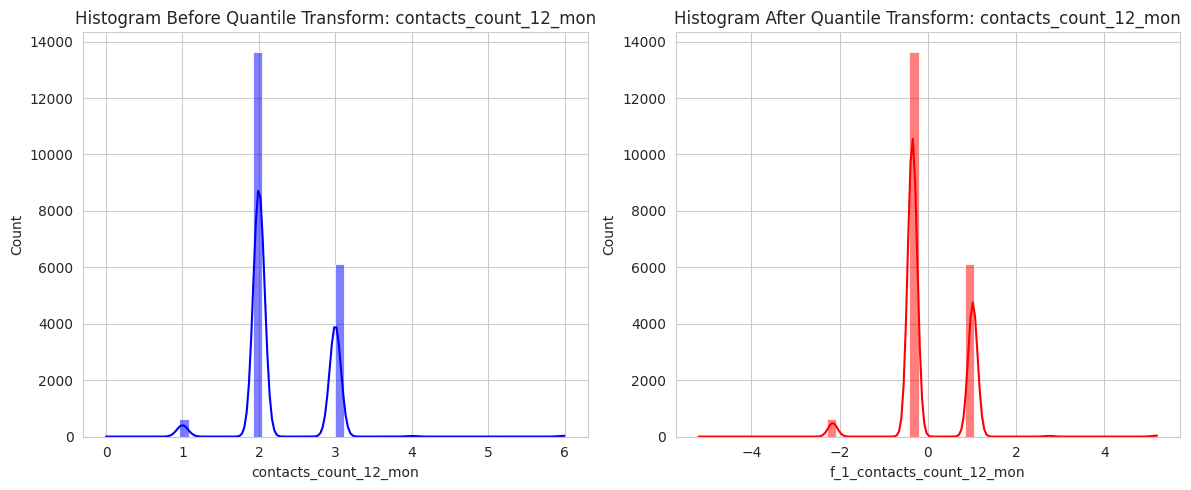

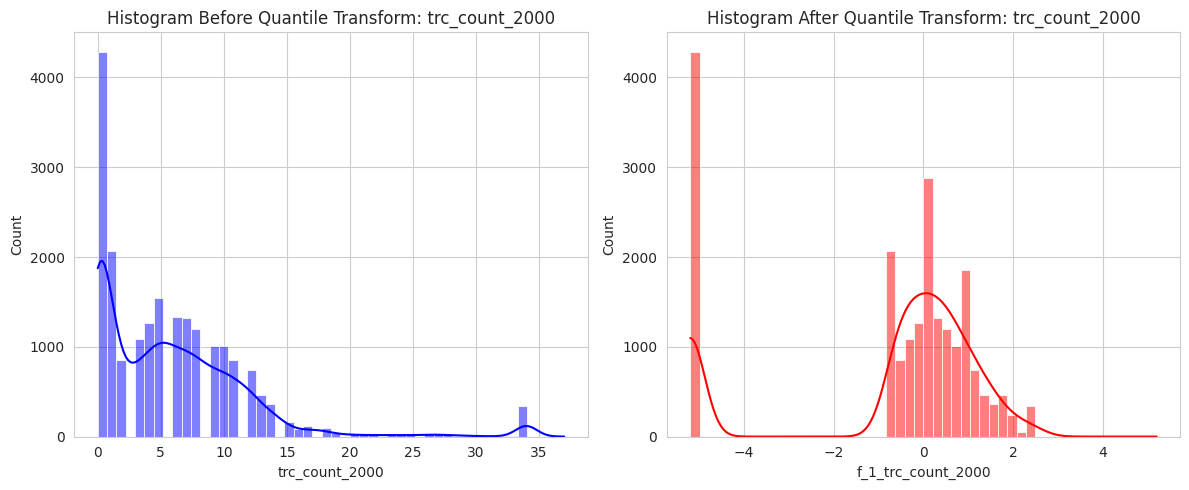

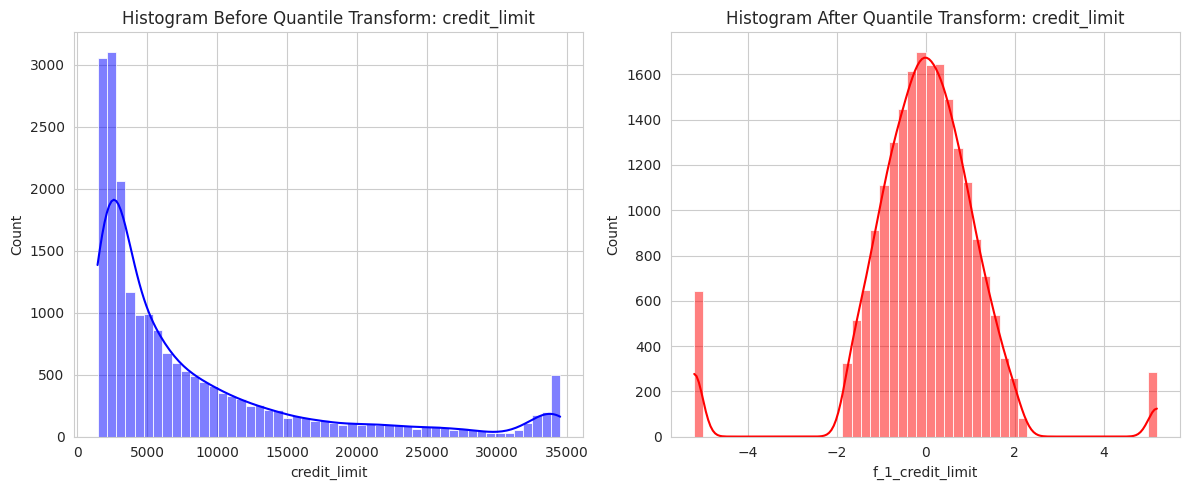

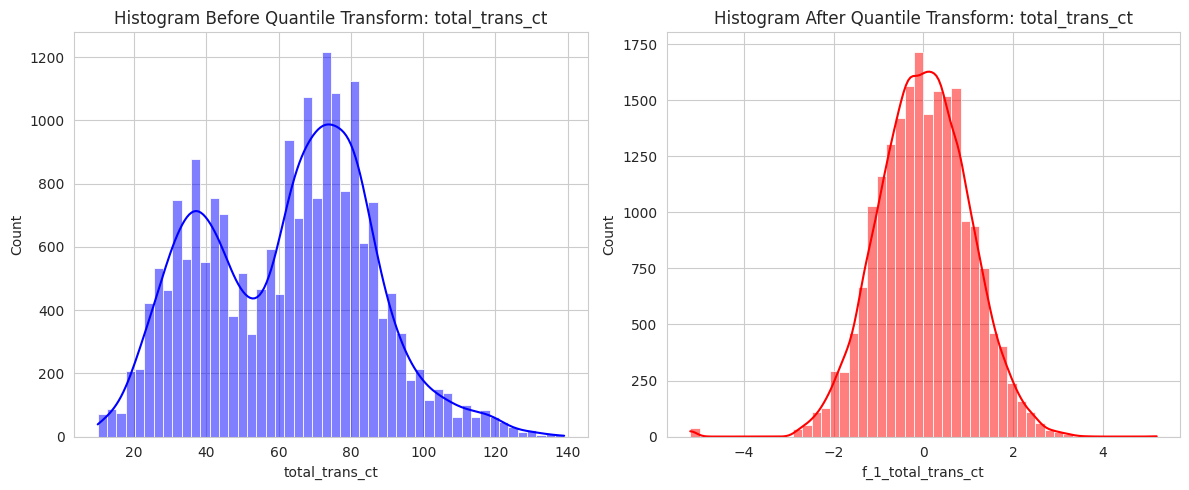

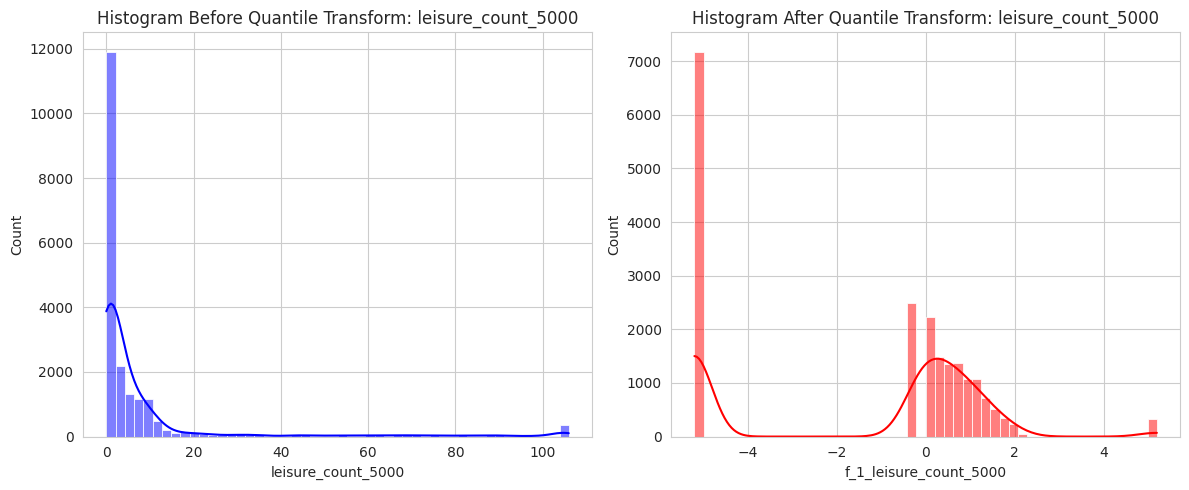

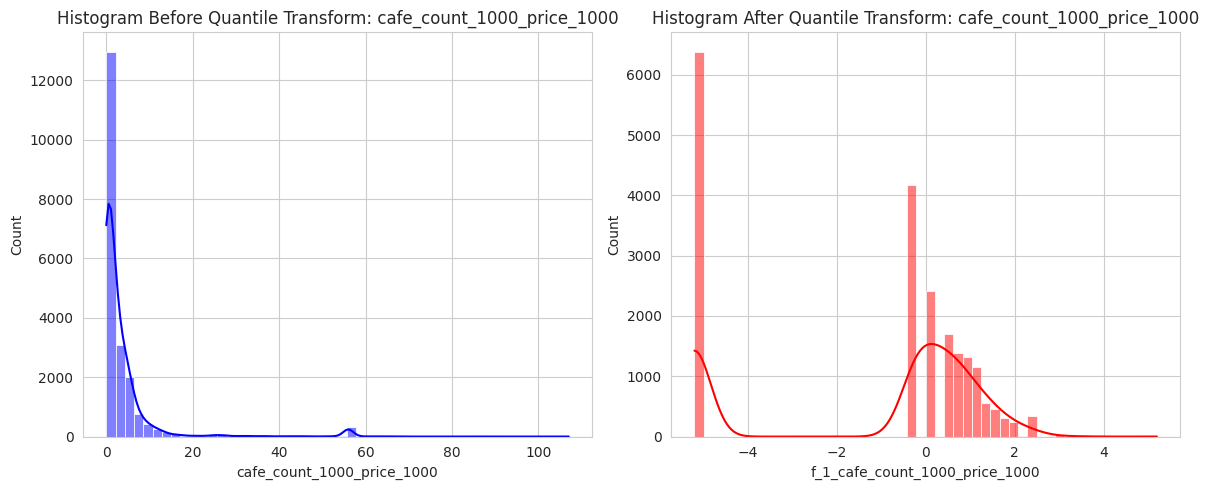

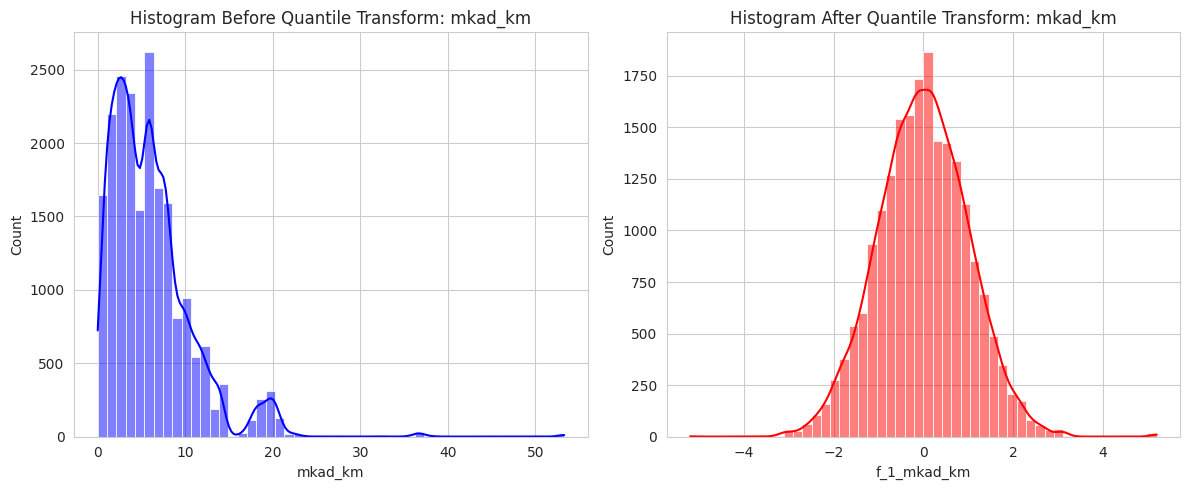

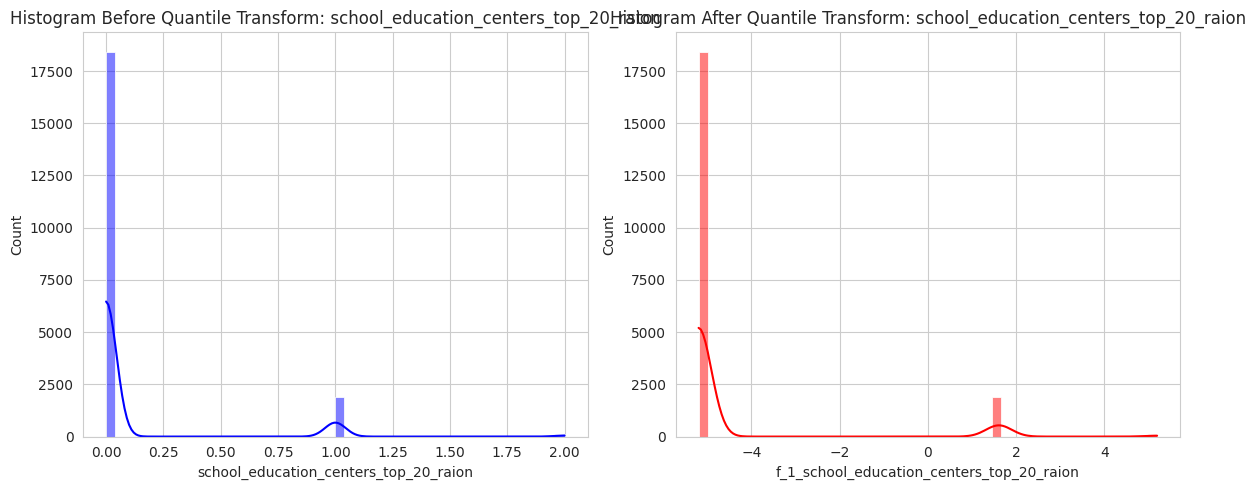

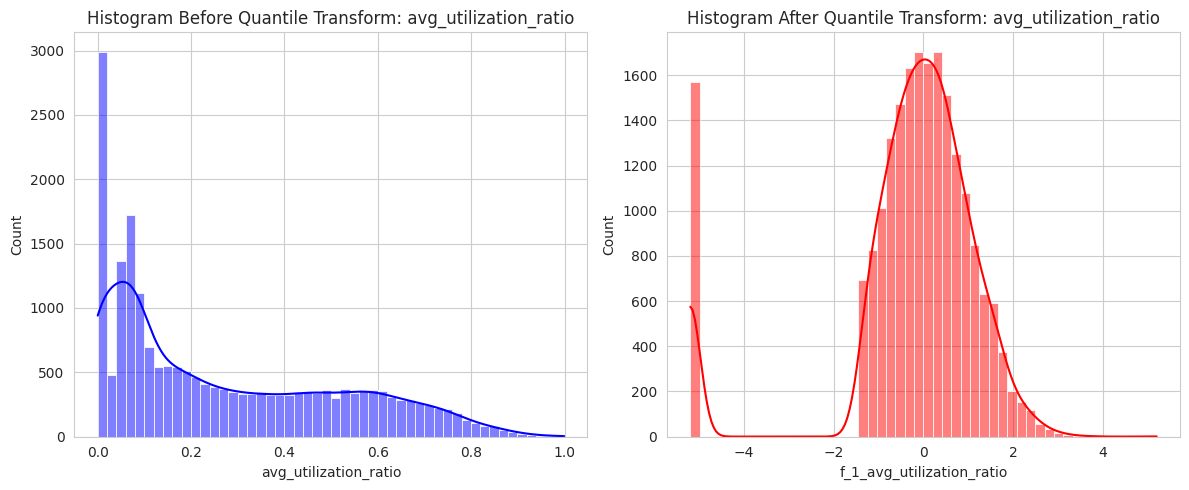

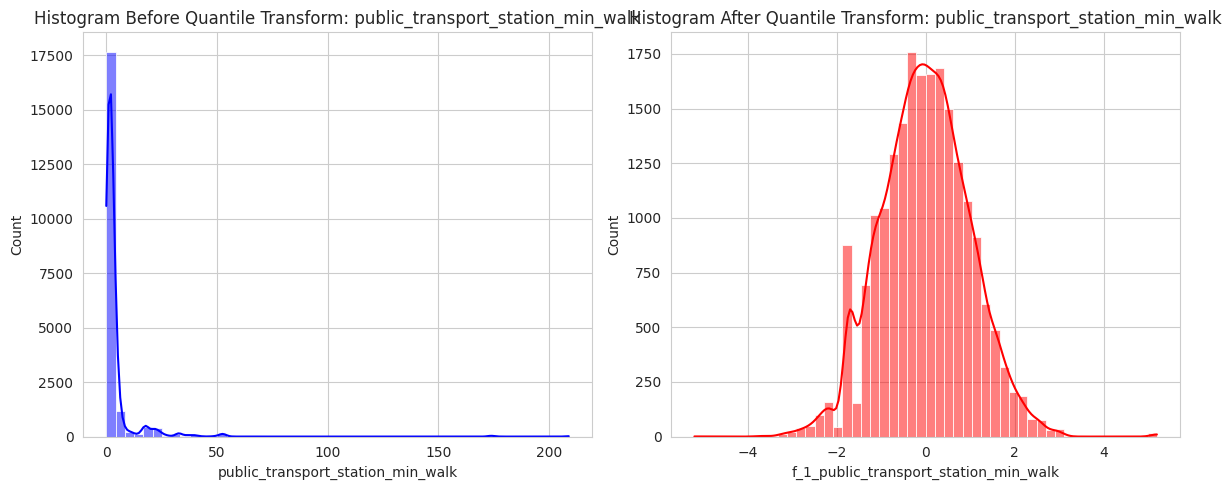

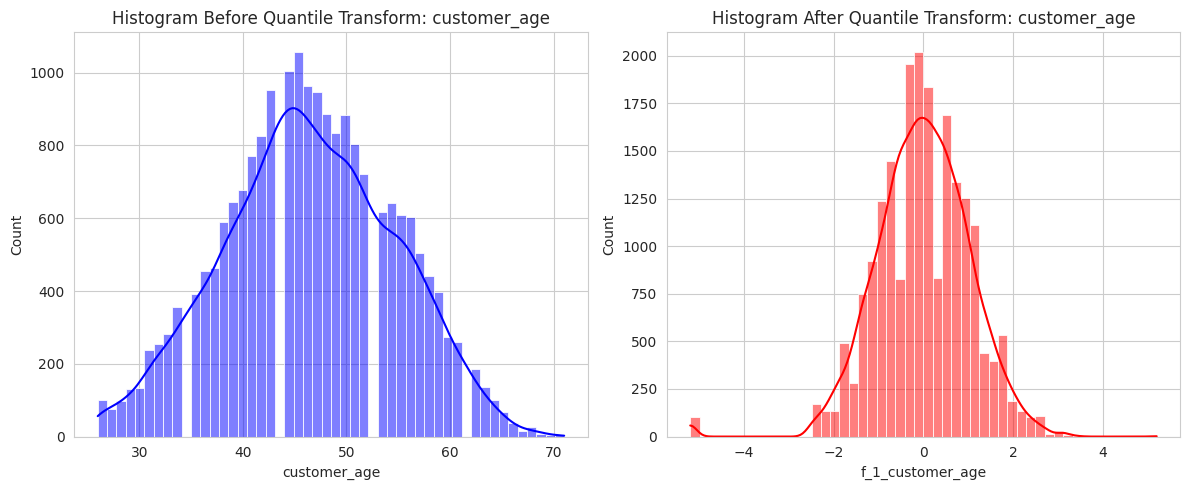

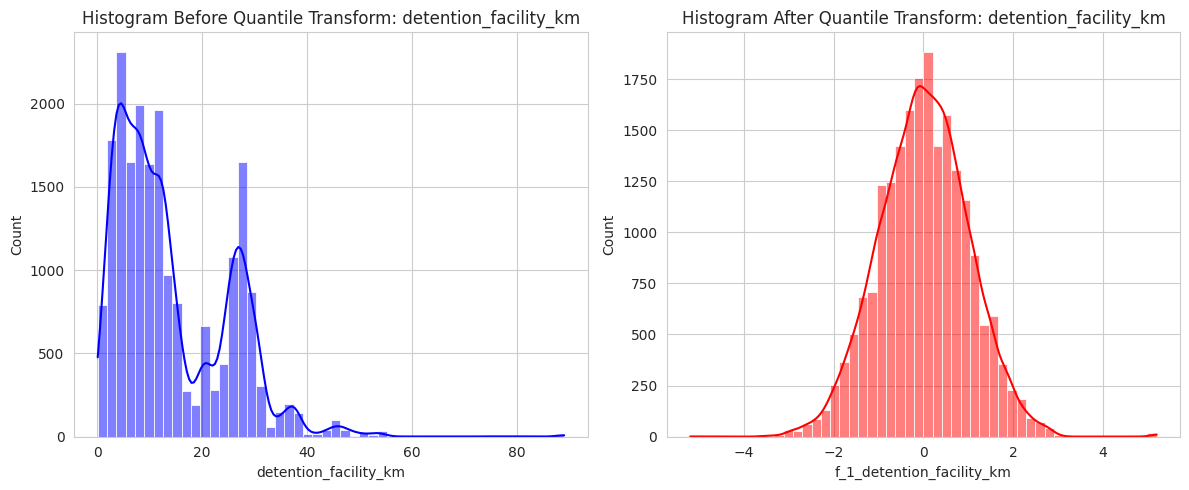

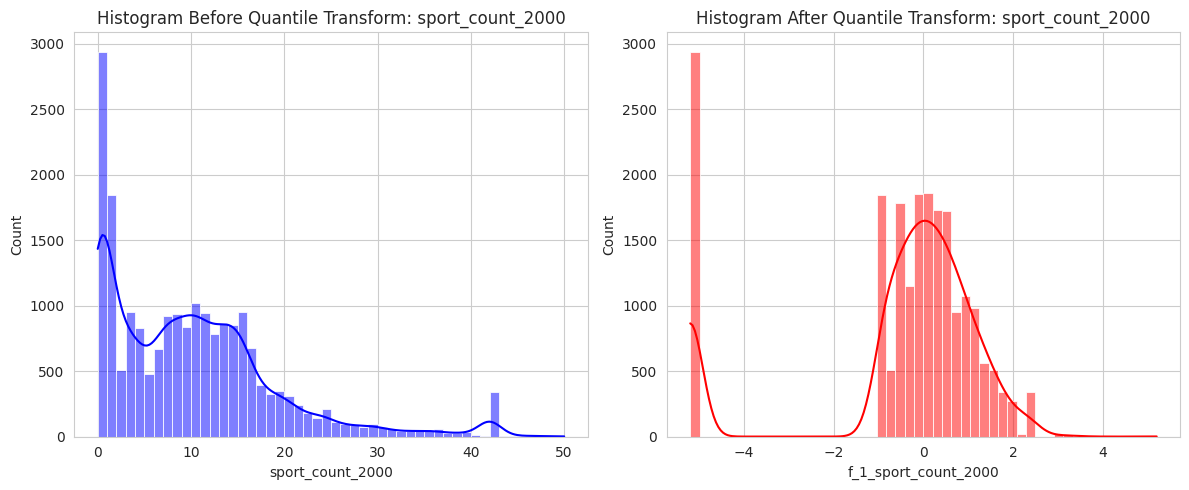

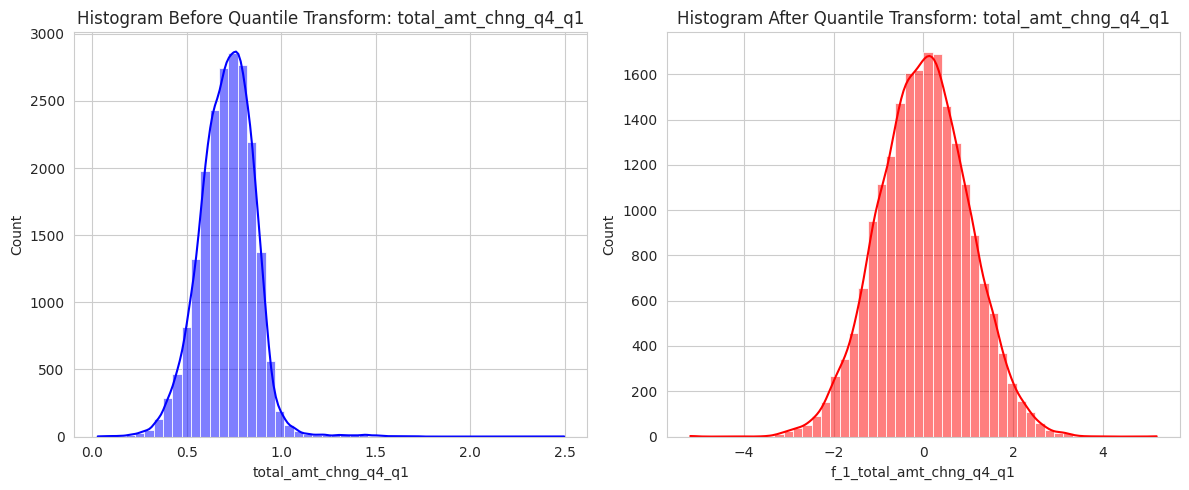

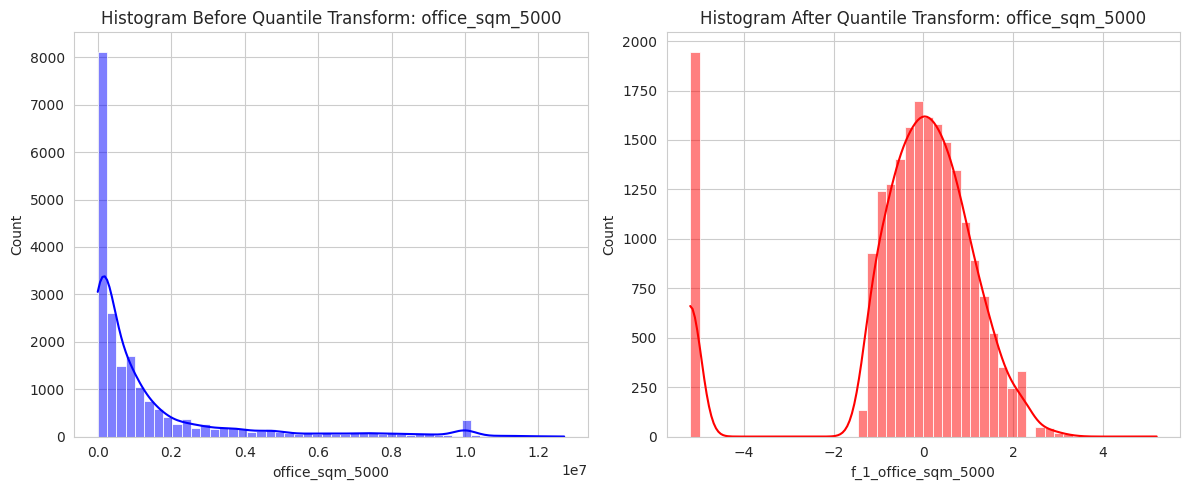

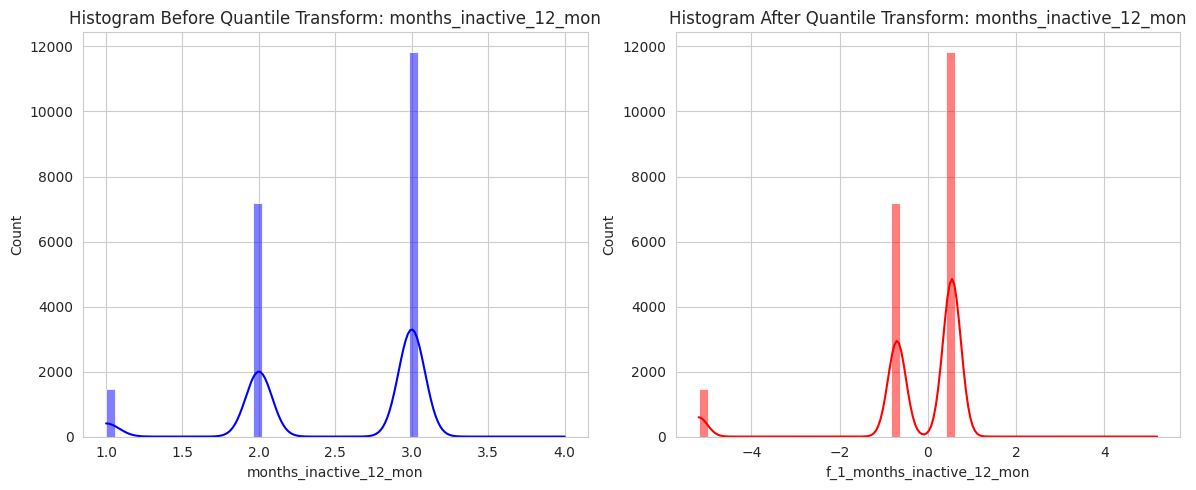

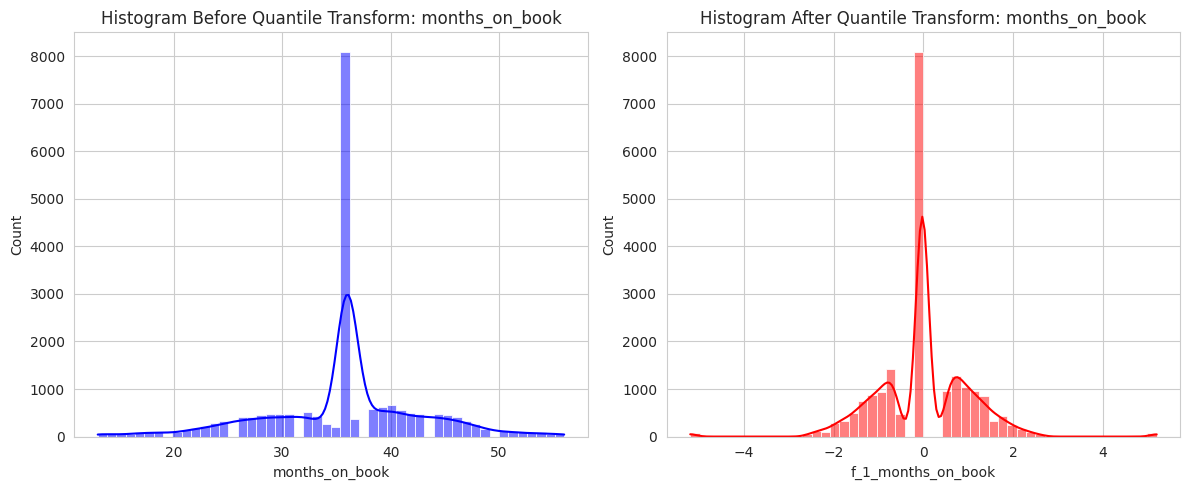

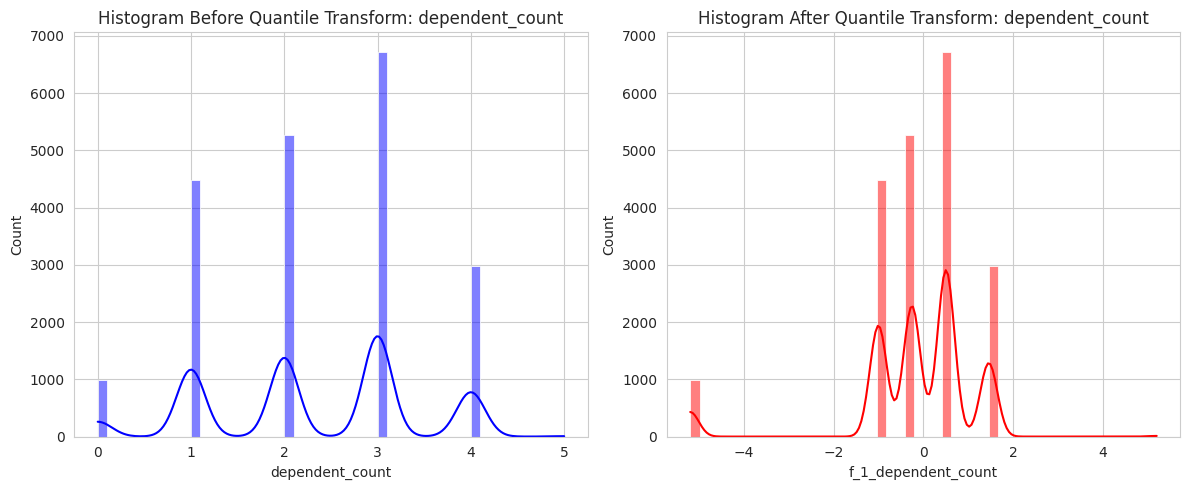

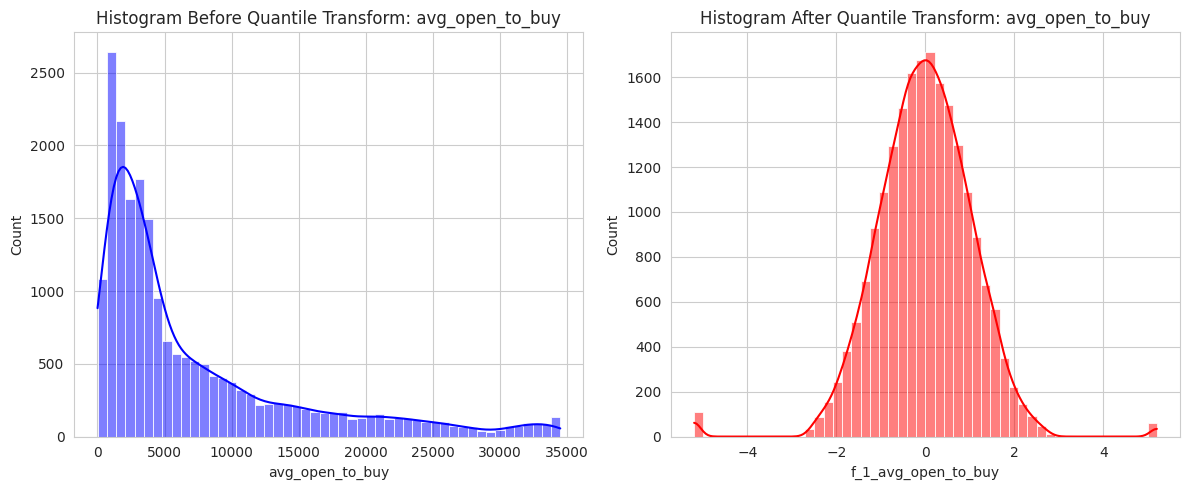

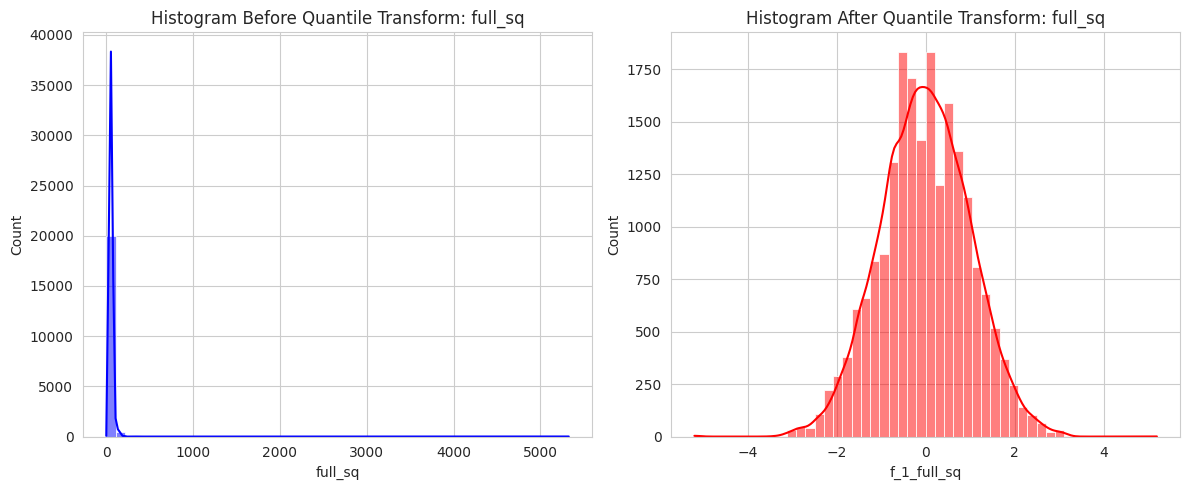

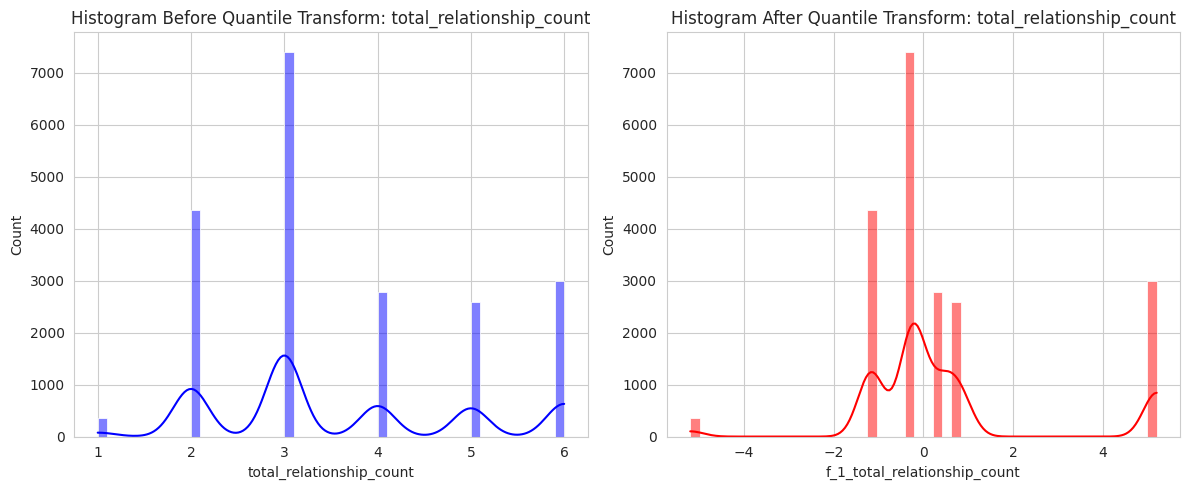

In [49]:
#histogram of normalized features (f_1_)
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set_style("whitegrid")


# Loop through each feature and plot before/after transformation
for feature in all_old_features:
    transformed_feature = f'f_1_{feature}'  # Transformed feature name

    # Check if both original and transformed features exist
    if feature in transform_train.columns and transformed_feature in transform_train.columns:
        fig, ax = plt.subplots(1, 2, figsize=(12, 5))

        # Histogram Before Transformation
        sns.histplot(transform_train[feature], bins=50, kde=True, ax=ax[0], color='blue')
        ax[0].set_title(f"Histogram Before Quantile Transform: {feature}")
        ax[0].set_xlabel(feature)

        # Histogram After Transformation
        sns.histplot(transform_train[transformed_feature], bins=50, kde=True, ax=ax[1], color='red')
        ax[1].set_title(f"Histogram After Quantile Transform: {feature}")
        ax[1].set_xlabel(transformed_feature)

        plt.tight_layout()
        plt.show()
    else:
        print(f"⚠️ Feature '{feature}' or its transformed version '{transformed_feature}' is missing.")


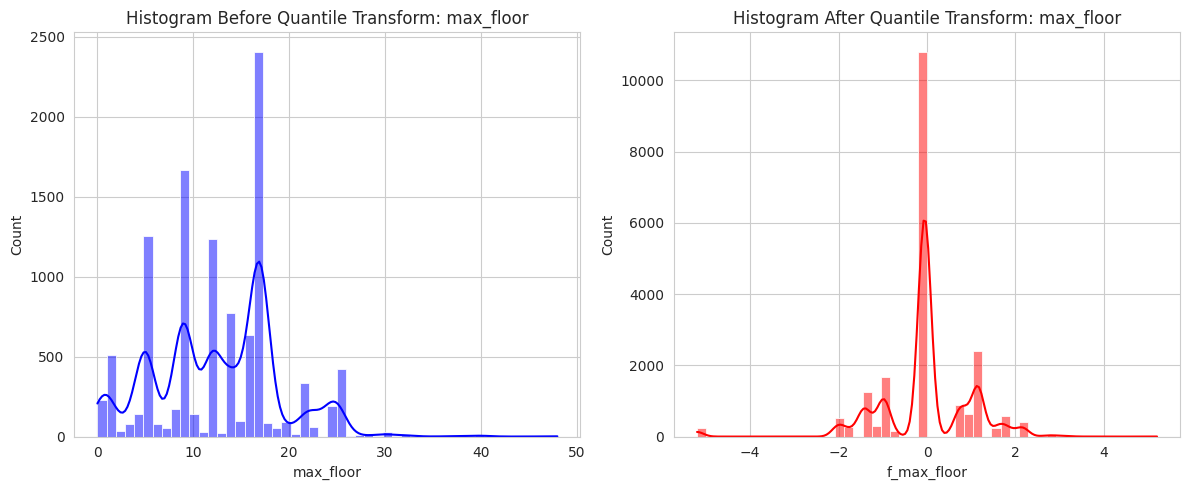

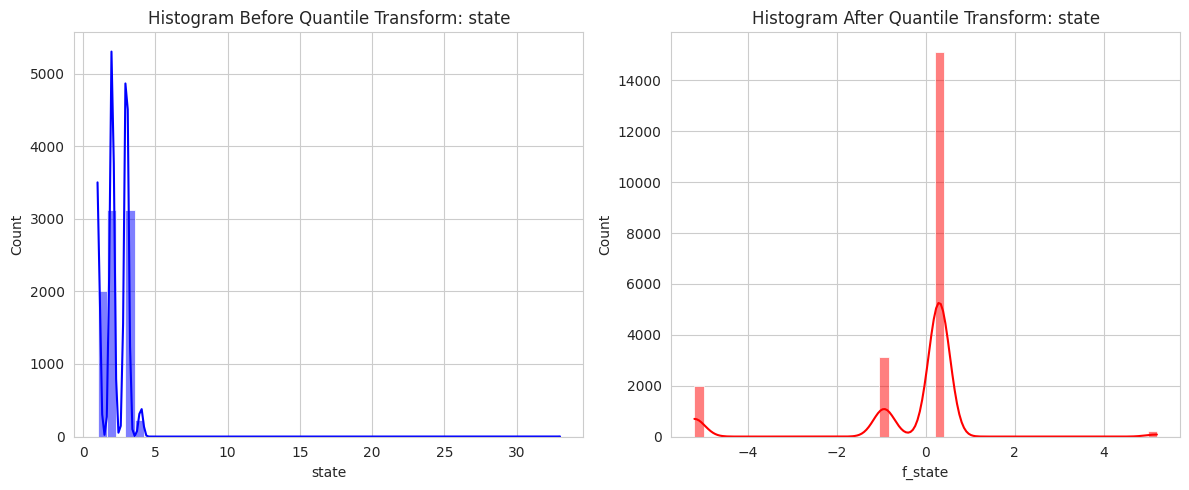

⚠️ Feature 'total_revolving_bal' or its transformed version 'f_total_revolving_bal' is missing.
⚠️ Feature 'market_count_1500' or its transformed version 'f_market_count_1500' is missing.
⚠️ Feature 'leisure_count_3000' or its transformed version 'f_leisure_count_3000' is missing.
⚠️ Feature 'total_ct_chng_q4_q1' or its transformed version 'f_total_ct_chng_q4_q1' is missing.


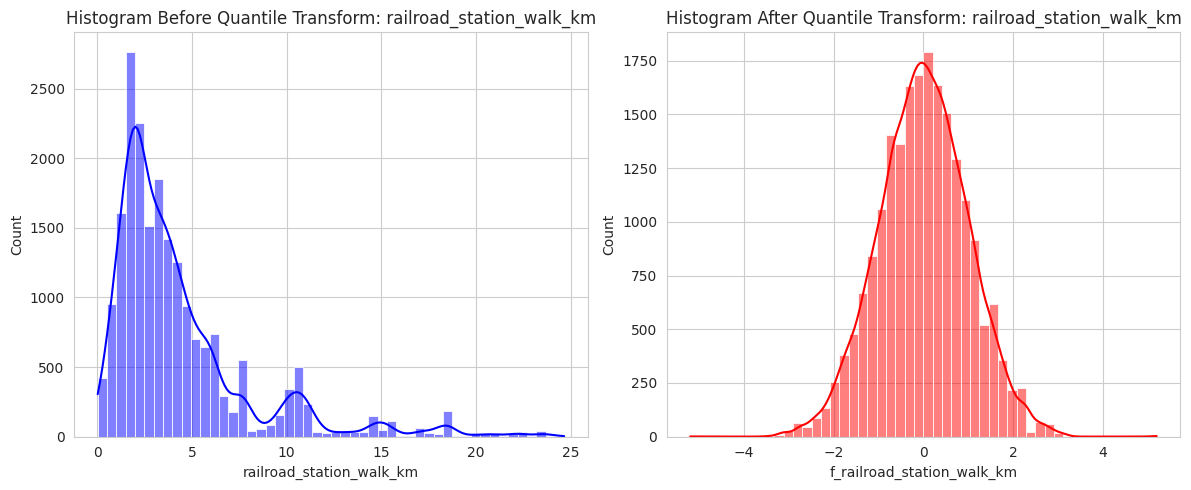

⚠️ Feature 'contacts_count_12_mon' or its transformed version 'f_contacts_count_12_mon' is missing.


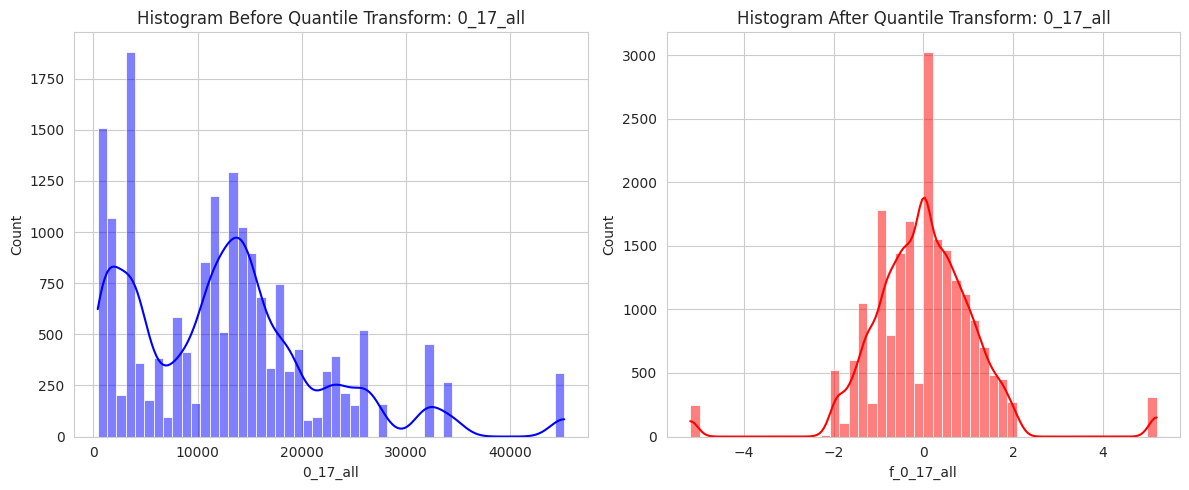

⚠️ Feature 'trc_count_2000' or its transformed version 'f_trc_count_2000' is missing.


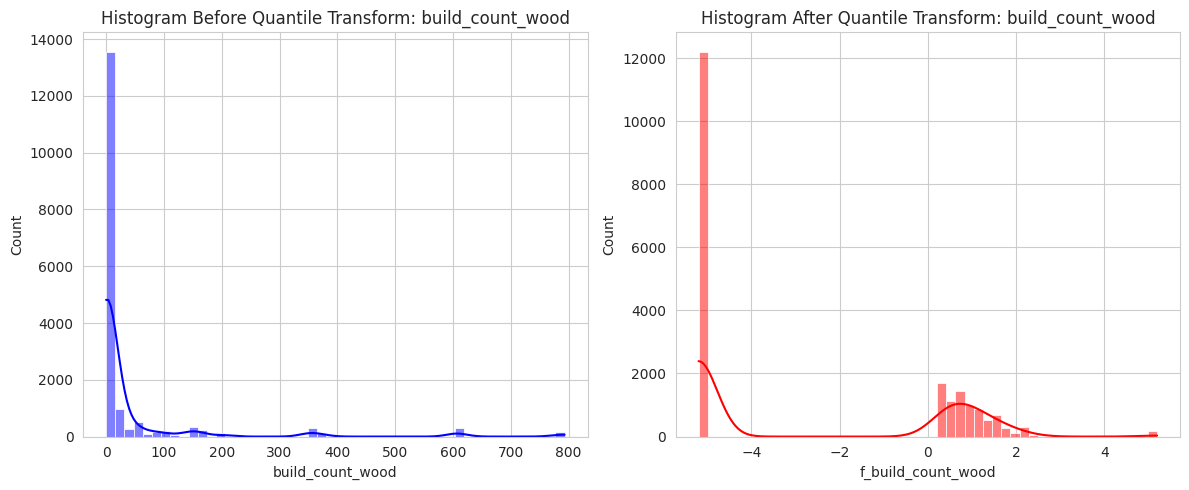

⚠️ Feature 'credit_limit' or its transformed version 'f_credit_limit' is missing.
⚠️ Feature 'total_trans_ct' or its transformed version 'f_total_trans_ct' is missing.
⚠️ Feature 'leisure_count_5000' or its transformed version 'f_leisure_count_5000' is missing.


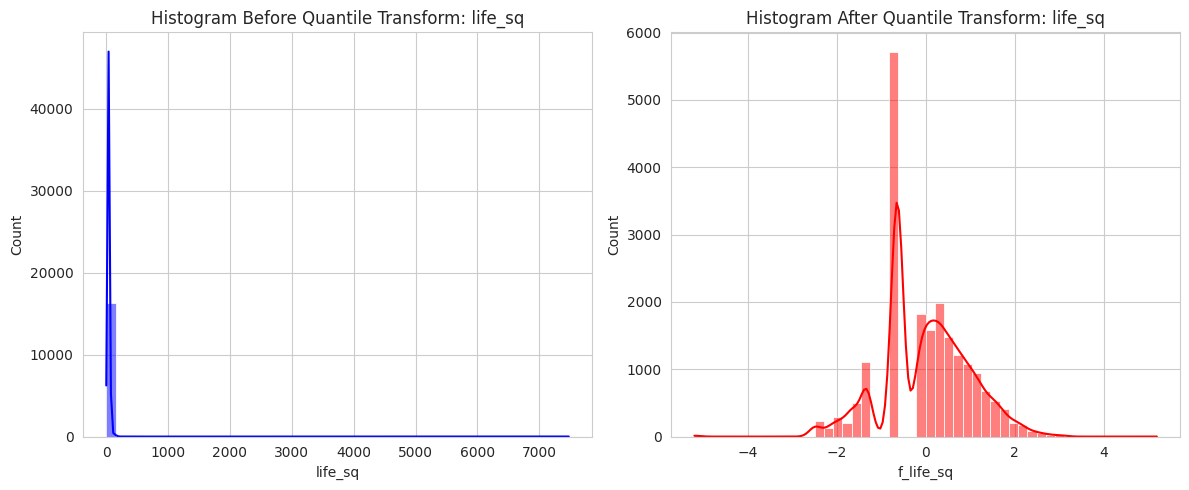

⚠️ Feature 'cafe_count_1000_price_1000' or its transformed version 'f_cafe_count_1000_price_1000' is missing.
⚠️ Feature 'mkad_km' or its transformed version 'f_mkad_km' is missing.
⚠️ Feature 'school_education_centers_top_20_raion' or its transformed version 'f_school_education_centers_top_20_raion' is missing.
⚠️ Feature 'avg_utilization_ratio' or its transformed version 'f_avg_utilization_ratio' is missing.
⚠️ Feature 'public_transport_station_min_walk' or its transformed version 'f_public_transport_station_min_walk' is missing.
⚠️ Feature 'customer_age' or its transformed version 'f_customer_age' is missing.
⚠️ Feature 'detention_facility_km' or its transformed version 'f_detention_facility_km' is missing.
⚠️ Feature 'sport_count_2000' or its transformed version 'f_sport_count_2000' is missing.


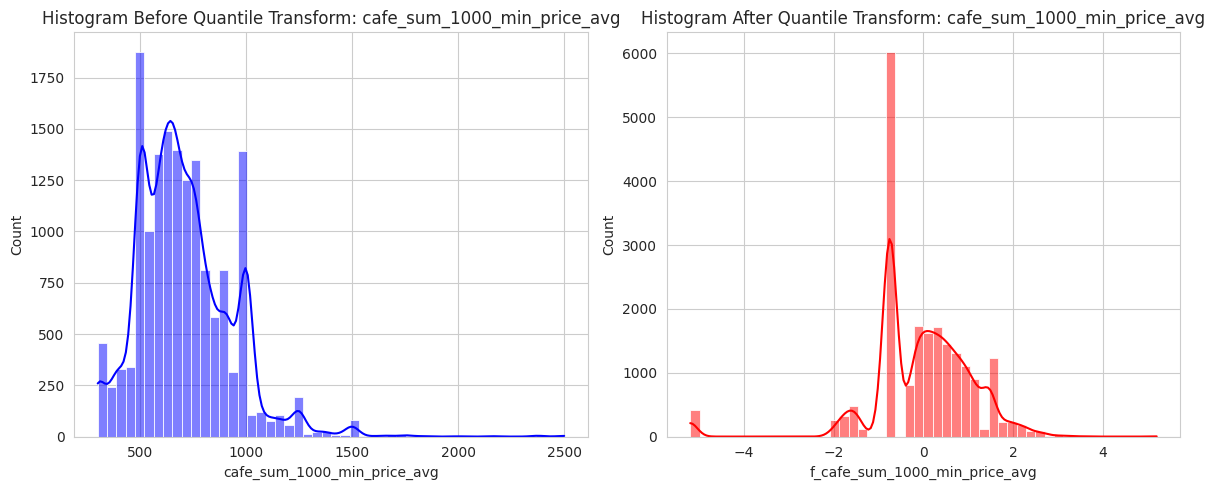

⚠️ Feature 'total_amt_chng_q4_q1' or its transformed version 'f_total_amt_chng_q4_q1' is missing.


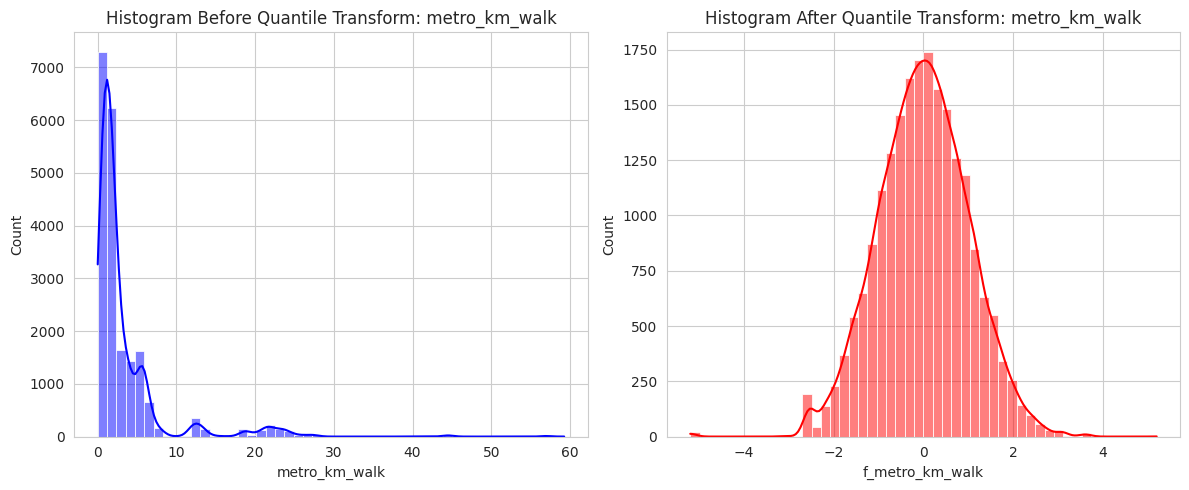

⚠️ Feature 'office_sqm_5000' or its transformed version 'f_office_sqm_5000' is missing.


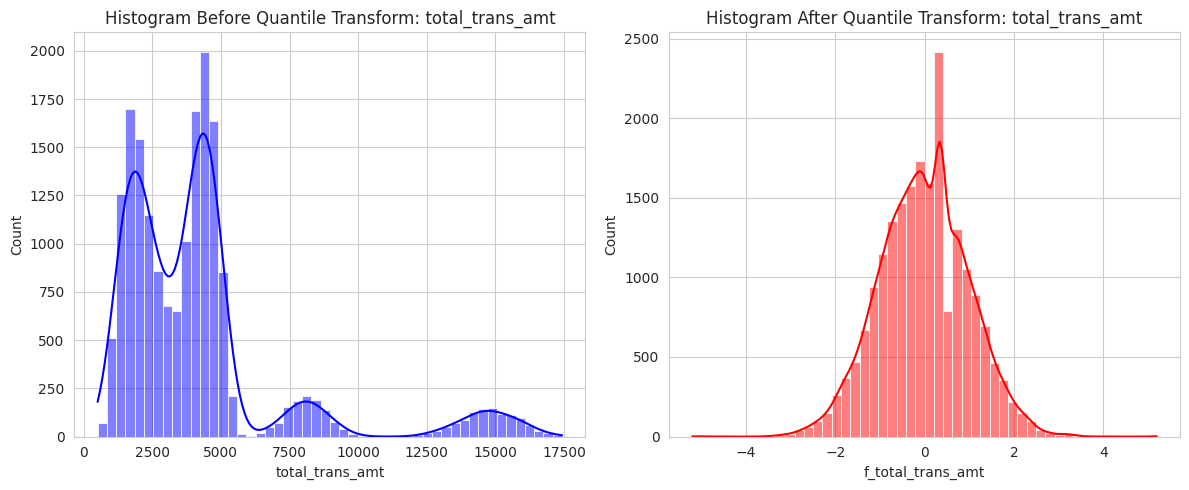

⚠️ Feature 'months_inactive_12_mon' or its transformed version 'f_months_inactive_12_mon' is missing.


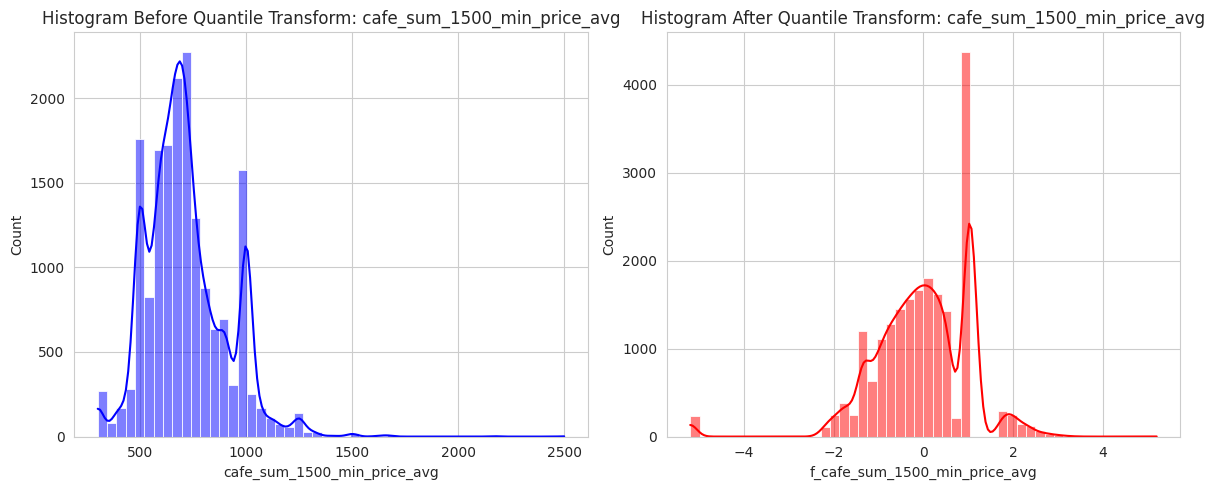

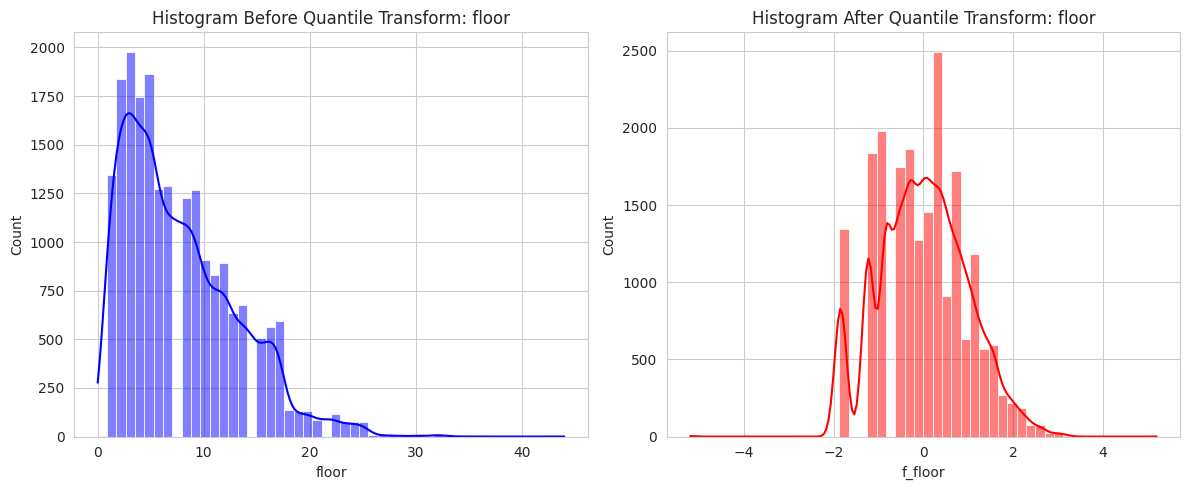

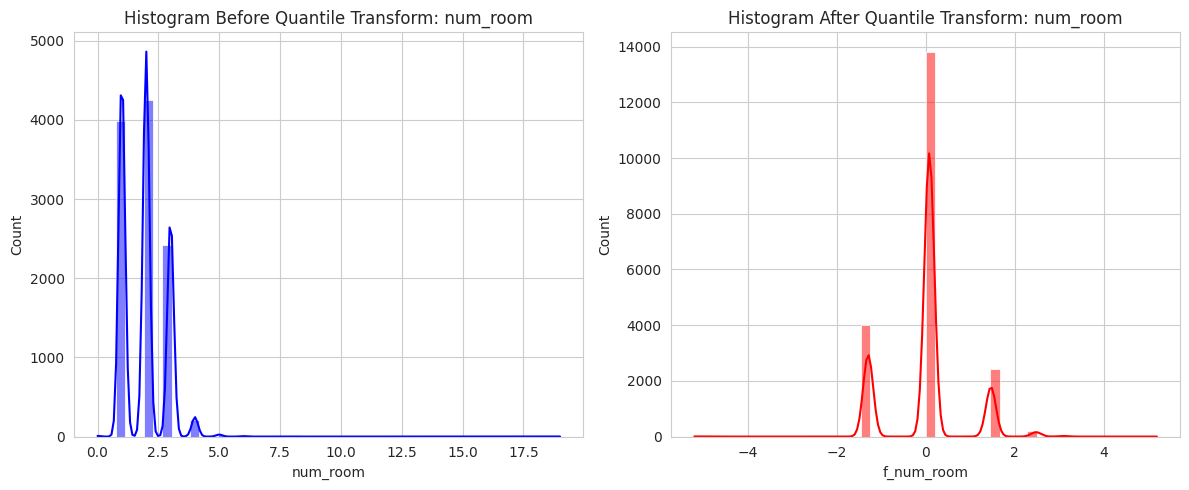

⚠️ Feature 'months_on_book' or its transformed version 'f_months_on_book' is missing.
⚠️ Feature 'dependent_count' or its transformed version 'f_dependent_count' is missing.
⚠️ Feature 'avg_open_to_buy' or its transformed version 'f_avg_open_to_buy' is missing.


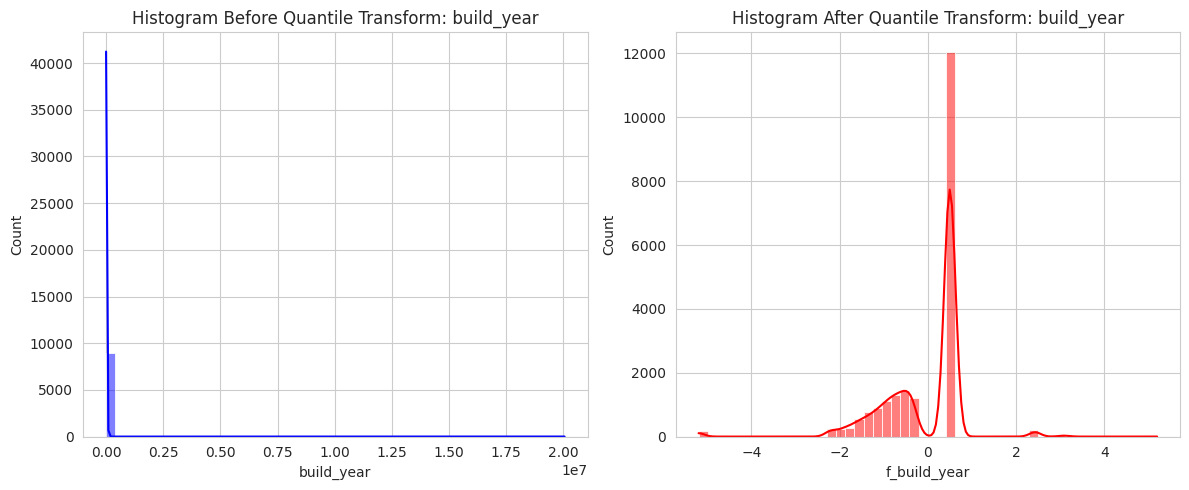

⚠️ Feature 'full_sq' or its transformed version 'f_full_sq' is missing.
⚠️ Feature 'total_relationship_count' or its transformed version 'f_total_relationship_count' is missing.


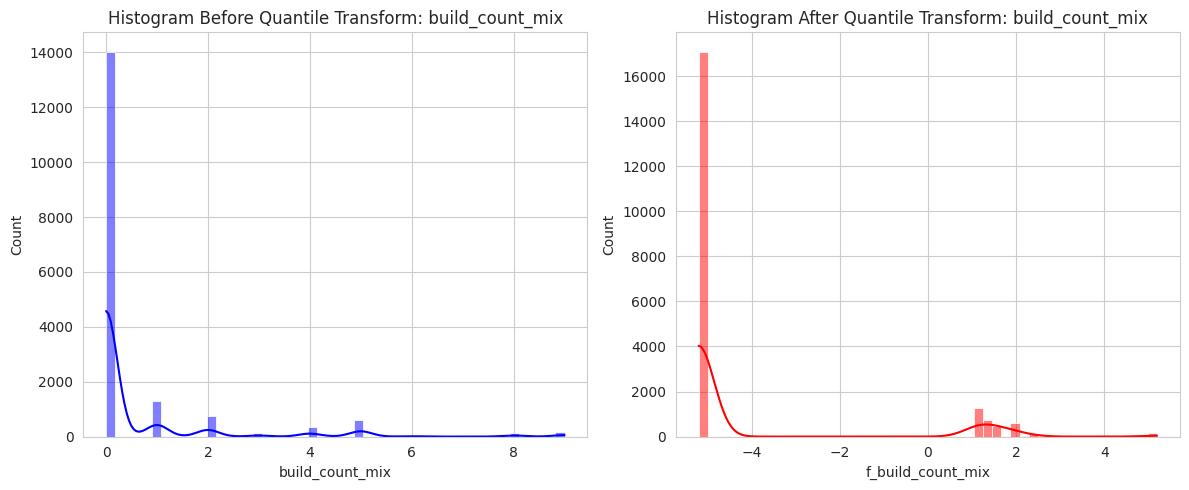

In [51]:
#histogram of normalized features (f_)

# Set style
sns.set_style("whitegrid")

#select feature colums
features_before = [col for col in transform_train.select_dtypes(include=['int64', 'float64'])
if not col.startswith('f_') and col not in ['__churn',
 '__price_doc'] ]

# Loop through each feature and plot before/after transformation
for feature in features_before:
    transformed_feature = f'f_{feature}'  # Transformed feature name

    # Check if both original and transformed features exist
    if feature in transform_train.columns and transformed_feature in transform_train.columns:
        fig, ax = plt.subplots(1, 2, figsize=(12, 5))

        # Histogram Before Transformation
        sns.histplot(transform_train[feature], bins=50, kde=True, ax=ax[0], color='blue')
        ax[0].set_title(f"Histogram Before Quantile Transform: {feature}")
        ax[0].set_xlabel(feature)

        # Histogram After Transformation
        sns.histplot(transform_train[transformed_feature], bins=50, kde=True, ax=ax[1], color='red')
        ax[1].set_title(f"Histogram After Quantile Transform: {feature}")
        ax[1].set_xlabel(transformed_feature)

        plt.tight_layout()
        plt.show()
    else:
        print(f"⚠️ Feature '{feature}' or its transformed version '{transformed_feature}' is missing.")


In [52]:
transform_train.shape, transform_test.shape

((20483, 127), (9183, 126))

In [ ]:
#check to see if the columns below were not altered after the transformation
columns___ =['state', 'railroad_station_walk_km', 'build_count_wood',
      'life_sq', 'cafe_sum_1000_min_price_avg', 'metro_km_walk',
      'cafe_sum_1500_min_price_avg', 'build_year', 'build_count_mix']
select = train[columns___]

select.head(20).T

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19
state,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
railroad_station_walk_km,5.419893,3.411993,1.277658,4.291432,0.853960,0.375312,2.603671,4.309575,1.540958,2.522422,3.432120,4.978186,0.635649,1.254206,0.904529,3.681023,2.393325,2.400835,3.788198,3.774845
build_count_wood,0.000000,1.000000,0.000000,51.000000,0.000000,0.000000,1.000000,0.000000,2.000000,204.000000,793.000000,11.000000,204.000000,6.000000,0.000000,0.000000,0.000000,0.000000,793.000000,0.000000
life_sq,27.000000,19.000000,29.000000,50.000000,77.000000,46.000000,14.000000,44.000000,27.000000,21.000000,19.000000,19.000000,28.000000,31.000000,21.000000,31.000000,31.000000,28.000000,33.000000,29.000000
cafe_sum_1000_min_price_avg,527.780000,615.380000,642.860000,658.330000,763.450000,883.330000,760.000000,784.620000,566.670000,620.000000,750.000000,NaN,575.000000,989.580000,554.840000,590.910000,600.000000,577.780000,750.000000,660.000000
metro_km_walk,1.131260,0.635053,1.445960,0.963802,0.688859,1.531514,1.026916,0.960649,1.228524,0.396275,1.238349,2.306504,1.623329,1.214706,0.590130,1.045237,0.621104,1.177877,1.428758,1.326009
cafe_sum_1500_min_price_avg,566.670000,694.120000,516.670000,673.910000,766.800000,718.180000,673.170000,585.710000,592.310000,788.890000,750.000000,766.670000,630.770000,1019.300000,544.120000,613.790000,581.250000,735.710000,750.000000,705.260000
build_year,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
build_count_mix,0.000000,0.000000,0.000000,2.000000,1.000000,0.000000,1.000000,0.000000,0.000000,1.000000,9.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,9.000000,0.000000


In [ ]:
#Apparently they are still the same
select1 = transform_train[columns___]

select1.head(20).T

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19
state,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
railroad_station_walk_km,5.419893,3.411993,1.277658,4.291432,0.853960,0.375312,2.603671,4.309575,1.540958,2.522422,3.432120,4.978186,0.635649,1.254206,0.904529,3.681023,2.393325,2.400835,3.788198,3.774845
build_count_wood,0.000000,1.000000,0.000000,51.000000,0.000000,0.000000,1.000000,0.000000,2.000000,204.000000,793.000000,11.000000,204.000000,6.000000,0.000000,0.000000,0.000000,0.000000,793.000000,0.000000
life_sq,27.000000,19.000000,29.000000,50.000000,77.000000,46.000000,14.000000,44.000000,27.000000,21.000000,19.000000,19.000000,28.000000,31.000000,21.000000,31.000000,31.000000,28.000000,33.000000,29.000000
cafe_sum_1000_min_price_avg,527.780000,615.380000,642.860000,658.330000,763.450000,883.330000,760.000000,784.620000,566.670000,620.000000,750.000000,NaN,575.000000,989.580000,554.840000,590.910000,600.000000,577.780000,750.000000,660.000000
metro_km_walk,1.131260,0.635053,1.445960,0.963802,0.688859,1.531514,1.026916,0.960649,1.228524,0.396275,1.238349,2.306504,1.623329,1.214706,0.590130,1.045237,0.621104,1.177877,1.428758,1.326009
cafe_sum_1500_min_price_avg,566.670000,694.120000,516.670000,673.910000,766.800000,718.180000,673.170000,585.710000,592.310000,788.890000,750.000000,766.670000,630.770000,1019.300000,544.120000,613.790000,581.250000,735.710000,750.000000,705.260000
build_year,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
build_count_mix,0.000000,0.000000,0.000000,2.000000,1.000000,0.000000,1.000000,0.000000,0.000000,1.000000,9.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,9.000000,0.000000


Submission

In [53]:
import os

# Ensure the save directory exists
save_dir = "/content/"
os.makedirs(save_dir, exist_ok=True)  # Creates the directory if it doesn't exist


if transform_train.shape[0] != TRAIN_SHAPE[0]:
    raise ValueError(f'Incorrect train file shape. Original {TRAIN_SHAPE[0]}. {transform_train.shape[0]} are given')
# index must be True
transform_train.to_csv(f'{save_dir}/1_{NAME}_train.csv', index=True)

if transform_test.shape[0] != TEST_SHAPE[0]:
    raise ValueError(f'Incorrect test file shape. Original {TEST_SHAPE[0]}. {transform_test.shape[0]} are given')
# index must be True
transform_test.to_csv(f'{save_dir}/1_{NAME}_test.csv', index=True)

print("Files saved successfully!")

Files saved successfully!
